In [1]:
# ============================================================
# PHASE 16 — MANUSCRIPT FIGURES PACKAGE
# ============================================================
# Goal:
# Create publication-ready visual summaries for the manuscript.
#
# Figures generated:
# 1. Overall workflow diagram
# 2. Held-out model performance comparison
# 3. Repeated-split performance comparison
# 4. Paired DNABERT2 vs Handcrafted delta plot
# 5. Block-level permutation importance / modality contribution
# 6. Candidate gene x pathway heatmap
# 7. Pathway summary bar plot
# 8. Biological validation summary plot
# 9. Final figure index / manuscript placement table
#
# This phase is designed to reduce dependence on large tables.
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import json
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

pd.set_option("display.max_columns", 250)
pd.set_option("display.max_colwidth", 500)

import os
from pathlib import Path
import pandas as pd
from google.colab import drive

try:
    drive.mount('/content/drive')
except ValueError:
    print("Drive đã được kết nối từ trước.")

PROJECT_DIR = Path("/content/drive/MyDrive/Project_Protein")

PHASE3_DIR = PROJECT_DIR / "model" / "phase3_multimodal_integration"
PHASE5_DIR = PROJECT_DIR / "model" / "phase5_dnabert2_extension"
PHASE7_DIR = PROJECT_DIR / "model" / "phase7_statistical_evidence"
PHASE8_DIR = PROJECT_DIR / "model" / "phase8_expanded_biological_validation"
PHASE10_DIR = PROJECT_DIR / "model" / "phase10_final_modality_contribution_visualization"
PHASE11_DIR = PROJECT_DIR / "model" / "phase11_repeated_split_seed_robustness"
PHASE12_DIR = PROJECT_DIR / "model" / "phase12_random_gene_set_enrichment_baseline"
PHASE13_DIR = PROJECT_DIR / "model" / "phase13_statistical_and_claim_calibration"
PHASE14_DIR = PROJECT_DIR / "model" / "phase14_explainability_analysis"
PHASE14C_DIR = PROJECT_DIR / "model" / "phase14c_recover_real_genomic_feature_names"
PHASE15_DIR = PROJECT_DIR / "model" / "phase15_biological_literature_support"

PHASE16_DIR = PROJECT_DIR / "model" / "phase16_manuscript_figures_package"
RESULT_DIR = PHASE16_DIR / "results"
FIGURE_DIR = PHASE16_DIR / "figures"
EXCEL_DIR = PHASE16_DIR / "excel"
REPORT_DIR = PHASE16_DIR / "reports"

for d in [PHASE16_DIR, RESULT_DIR, FIGURE_DIR, EXCEL_DIR, REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Phase 16 output:", PHASE16_DIR)

Mounted at /content/drive
Phase 16 output: /content/drive/MyDrive/Project_Protein/model/phase16_manuscript_figures_package


In [2]:
# ============================================================
# HELPER FUNCTIONS
# ============================================================

def save_df(df, path):
    path = Path(path)
    df.to_csv(path, index=False)
    print("Saved:", path)


def round_numeric_columns(df, digits=4):
    df = df.copy()
    for col in df.columns:
        if pd.api.types.is_float_dtype(df[col]):
            df[col] = df[col].round(digits)
    return df


def read_csv_safe(path):
    path = Path(path)
    if path.exists():
        print("Loaded:", path)
        return pd.read_csv(path)
    print("Missing:", path)
    return None


def find_csv_by_keywords(base_dirs, required_keywords, optional_keywords=None):
    """
    Search CSV files whose path contains all required keywords.
    """
    if optional_keywords is None:
        optional_keywords = []

    candidates = []

    for base in base_dirs:
        base = Path(base)
        if not base.exists():
            continue

        for p in base.rglob("*.csv"):
            s = str(p).lower()

            if all(k.lower() in s for k in required_keywords):
                score = sum(k.lower() in s for k in optional_keywords)
                candidates.append((score, p))

    candidates = sorted(candidates, key=lambda x: (-x[0], len(str(x[1]))))

    return [p for score, p in candidates]


def wrap_label(s, width=18):
    return "\n".join(textwrap.wrap(str(s), width=width))


def save_current_figure(path):
    path = Path(path)
    plt.savefig(path, dpi=300, bbox_inches="tight")
    print("Saved:", path)


def standardize_model_name(x):
    s = str(x)

    mapping = {
        "Genomic-only K3/K4/Basic": "Genomic-only",
        "Protein-only ProtBERT-SW SVM": "Protein-only",
        "Handcrafted multimodal SVM": "Handcrafted\nmultimodal",
        "DNABERT2 multimodal SVM": "DNABERT-2\nmultimodal",
        "DNABERT-2 multimodal SVM": "DNABERT-2\nmultimodal",
        "DNABERT2": "DNABERT-2",
        "Handcrafted": "Handcrafted",
        "Protein": "Protein-only",
        "Genomic": "Genomic-only"
    }

    return mapping.get(s, s)


def compact_metric_name(x):
    s = str(x).lower()
    mapping = {
        "roc_auc": "ROC-AUC",
        "roc": "ROC-AUC",
        "pr_auc": "PR-AUC",
        "pr": "PR-AUC",
        "f1": "F1",
        "mcc": "MCC",
        "accuracy": "Accuracy",
        "specificity": "Specificity",
        "recall": "Recall"
    }
    return mapping.get(s, str(x))


def make_manual_heldout_df():
    """
    Fallback held-out table from known project results.
    """
    records = [
        {
            "model": "Genomic-only",
            "roc_auc": 0.6397,
            "pr_auc": 0.6215,
            "f1": 0.5375,
            "mcc": 0.1372,
            "tn": 86,
            "fp": 50,
            "fn": 67,
            "tp": 68
        },
        {
            "model": "Protein-only",
            "roc_auc": 0.7274,
            "pr_auc": 0.7433,
            "f1": 0.6667,
            "mcc": 0.3215,
            "tn": 87,
            "fp": 49,
            "fn": 43,
            "tp": 92
        },
        {
            "model": "Handcrafted multimodal",
            "roc_auc": 0.7290,
            "pr_auc": 0.7573,
            "f1": 0.6590,
            "mcc": 0.3438,
            "tn": 96,
            "fp": 40,
            "fn": 49,
            "tp": 86
        },
        {
            "model": "DNABERT-2 multimodal",
            "roc_auc": 0.7568,
            "pr_auc": 0.7447,
            "f1": 0.6642,
            "mcc": 0.3433,
            "tn": 94,
            "fp": 42,
            "fn": 47,
            "tp": 88
        },
    ]

    return pd.DataFrame(records)


def make_manual_repeated_split_df():
    """
    Fallback repeated-split table from Phase 11 summary.
    """
    records = [
        {
            "model": "Genomic-only",
            "roc_auc_mean": 0.647,
            "roc_auc_sd": 0.036,
            "pr_auc_mean": 0.637,
            "pr_auc_sd": 0.041,
            "f1_mean": 0.577,
            "f1_sd": 0.071,
            "mcc_mean": 0.208,
            "mcc_sd": 0.049,
        },
        {
            "model": "Protein-only",
            "roc_auc_mean": 0.719,
            "roc_auc_sd": 0.024,
            "pr_auc_mean": 0.705,
            "pr_auc_sd": 0.030,
            "f1_mean": 0.651,
            "f1_sd": 0.071,
            "mcc_mean": 0.313,
            "mcc_sd": 0.029,
        },
        {
            "model": "Handcrafted multimodal",
            "roc_auc_mean": 0.735,
            "roc_auc_sd": 0.028,
            "pr_auc_mean": 0.725,
            "pr_auc_sd": 0.034,
            "f1_mean": 0.644,
            "f1_sd": 0.076,
            "mcc_mean": 0.325,
            "mcc_sd": 0.052,
        },
        {
            "model": "DNABERT-2 multimodal",
            "roc_auc_mean": 0.745,
            "roc_auc_sd": 0.030,
            "pr_auc_mean": 0.726,
            "pr_auc_sd": 0.035,
            "f1_mean": 0.667,
            "f1_sd": 0.081,
            "mcc_mean": 0.352,
            "mcc_sd": 0.073,
        },
    ]

    return pd.DataFrame(records)

In [3]:
# ============================================================
# LOAD OR CREATE HELD-OUT PERFORMANCE TABLE
# ============================================================

# Try to find existing final comparison files first.
candidate_files = find_csv_by_keywords(
    base_dirs=[PROJECT_DIR / "model"],
    required_keywords=["comparison"],
    optional_keywords=["final", "model", "table1", "held", "test"]
)

print("Comparison file candidates:")
for p in candidate_files[:20]:
    print(p)

heldout_df = None

# Try loading a relevant final table if it has required columns
for p in candidate_files:
    try:
        tmp = pd.read_csv(p)
        cols = [c.lower() for c in tmp.columns]

        if any("roc" in c for c in cols) and any("pr" in c for c in cols):
            heldout_df = tmp.copy()
            print("Using held-out table:", p)
            break
    except Exception:
        pass

# Fallback to manual known values
if heldout_df is None:
    heldout_df = make_manual_heldout_df()
    print("Using manually defined held-out results.")

# Normalize likely column names
rename_map = {}

for c in heldout_df.columns:
    cl = c.lower()

    if cl in ["model_name", "model"]:
        rename_map[c] = "model"
    elif cl in ["roc_auc", "test_roc_auc", "roc-aUC".lower()]:
        rename_map[c] = "roc_auc"
    elif cl in ["pr_auc", "test_pr_auc", "average_precision", "ap"]:
        rename_map[c] = "pr_auc"
    elif cl in ["f1", "test_f1"]:
        rename_map[c] = "f1"
    elif cl in ["mcc", "test_mcc"]:
        rename_map[c] = "mcc"

heldout_df = heldout_df.rename(columns=rename_map)

# If model column missing, create one
if "model" not in heldout_df.columns:
    heldout_df["model"] = [f"Model_{i}" for i in range(len(heldout_df))]

# Keep only relevant rows if too large
needed_cols = ["model", "roc_auc", "pr_auc", "f1", "mcc"]
available_needed_cols = [c for c in needed_cols if c in heldout_df.columns]
heldout_plot_df = heldout_df[available_needed_cols].copy()

# If metrics missing due to failed file parsing, fallback
if not all(c in heldout_plot_df.columns for c in ["roc_auc", "pr_auc", "f1", "mcc"]):
    heldout_plot_df = make_manual_heldout_df()[needed_cols].copy()

heldout_plot_df = round_numeric_columns(heldout_plot_df, 4)

display(heldout_plot_df)

save_df(
    heldout_plot_df,
    RESULT_DIR / "phase16_heldout_performance_table.csv"
)

Comparison file candidates:
/content/drive/MyDrive/Project_Protein/model/final_report_tables/csv/table1_final_model_comparison.csv
/content/drive/MyDrive/Project_Protein/model/phase6_final_consolidation/csv/table1_final_master_comparison_v2.csv
/content/drive/MyDrive/Project_Protein/model/phase6_final_consolidation/csv/table4_biological_validation_comparison.csv
/content/drive/MyDrive/Project_Protein/model/phase1_final_protein_analysis/results/final_protein_branch_master_comparison.csv
/content/drive/MyDrive/Project_Protein/model/phase2_2_genomic_analysis/results/phase2_2_final_protein_vs_genomic_comparison.csv
/content/drive/MyDrive/Project_Protein/model/phase4_biological_validation_preparation/results/phase4_0A_final_master_comparison_table.csv
/content/drive/MyDrive/Project_Protein/model/phase22_multimodal_fusion_strategy_comparison/results/phase22_paired_fusion_strategy_tests.csv
/content/drive/MyDrive/Project_Protein/model/phase10_final_modality_contribution_visualization/results/

,model,roc_auc,pr_auc,f1,mcc
0,SVM RBF,0.7290,0.7573,0.6590,0.3438
1,SVM RBF,0.7274,0.7433,0.6667,0.3215
2,SVM RBF,0.6765,0.6504,0.6620,0.2933
3,Random Forest,0.6496,0.6327,0.6406,0.2557
4,Logistic Regression,0.6487,0.6551,0.5896,0.1941
5,Logistic Regression,0.6371,0.6423,0.6014,0.1943
6,Soft Voting,0.6277,0.6278,0.5870,0.1650
7,Stacking,0.6202,0.6188,0.5926,0.1941
8,Soft Voting,0.5875,0.5942,0.5654,0.0995
9,Random Forest,0.5520,0.5550,0.5390,0.0480


Saved: /content/drive/MyDrive/Project_Protein/model/phase16_manuscript_figures_package/results/phase16_heldout_performance_table.csv


In [4]:

# ============================================================
# LOAD OR CREATE REPEATED-SPLIT PERFORMANCE TABLE
# ============================================================

candidate_files = find_csv_by_keywords(
    base_dirs=[PHASE11_DIR, PHASE13_DIR, PROJECT_DIR / "model"],
    required_keywords=["repeated"],
    optional_keywords=["summary", "seed", "robustness", "performance"]
)

print("Repeated-split file candidates:")
for p in candidate_files[:30]:
    print(p)

repeated_df = None

for p in candidate_files:
    try:
        tmp = pd.read_csv(p)
        cols = [c.lower() for c in tmp.columns]

        has_mean = any("mean" in c for c in cols)
        has_roc = any("roc" in c for c in cols)
        has_pr = any("pr" in c for c in cols)

        if has_mean and has_roc and has_pr:
            repeated_df = tmp.copy()
            print("Using repeated-split table:", p)
            break
    except Exception:
        pass

if repeated_df is None:
    repeated_plot_df = make_manual_repeated_split_df()
    print("Using manually defined repeated-split results.")
else:
    repeated_plot_df = repeated_df.copy()

    # Try to normalize model column
    for c in repeated_plot_df.columns:
        if c.lower() in ["model", "model_name", "configuration"]:
            repeated_plot_df = repeated_plot_df.rename(columns={c: "model"})
            break

    # If columns already look like mean/sd, keep
    required = [
        "roc_auc_mean", "roc_auc_sd",
        "pr_auc_mean", "pr_auc_sd",
        "f1_mean", "f1_sd",
        "mcc_mean", "mcc_sd"
    ]

    if not all(c in repeated_plot_df.columns for c in required):
        repeated_plot_df = make_manual_repeated_split_df()

repeated_plot_df = round_numeric_columns(repeated_plot_df, 4)

display(repeated_plot_df)

save_df(
    repeated_plot_df,
    RESULT_DIR / "phase16_repeated_split_performance_table.csv"
)

Repeated-split file candidates:
/content/drive/MyDrive/Project_Protein/model/phase11_repeated_split_seed_robustness/results/phase11_repeated_split_mean_sd_summary.csv
/content/drive/MyDrive/Project_Protein/model/phase11_repeated_split_seed_robustness/results/phase11_repeated_split_mean_sd_summary.csv
/content/drive/MyDrive/Project_Protein/model/phase11_repeated_split_seed_robustness/results/phase11_final_claims_table.csv
/content/drive/MyDrive/Project_Protein/model/phase11_repeated_split_seed_robustness/results/phase11_final_claims_table.csv
/content/drive/MyDrive/Project_Protein/model/phase11_repeated_split_seed_robustness/results/phase11_model_ranking_per_seed.csv
/content/drive/MyDrive/Project_Protein/model/phase11_repeated_split_seed_robustness/results/phase11_model_ranking_per_seed.csv
/content/drive/MyDrive/Project_Protein/model/phase11_repeated_split_seed_robustness/results/phase11_split_composition_by_seed.csv
/content/drive/MyDrive/Project_Protein/model/phase11_repeated_split_

,model_key,model_description,n_runs,roc_auc_mean,roc_auc_sd,roc_auc_median,roc_auc_min,roc_auc_max,pr_auc_mean,pr_auc_sd,pr_auc_median,pr_auc_min,pr_auc_max,accuracy_mean,accuracy_sd,accuracy_median,accuracy_min,accuracy_max,precision_mean,precision_sd,precision_median,precision_min,precision_max,recall_sensitivity_mean,recall_sensitivity_sd,recall_sensitivity_median,recall_sensitivity_min,recall_sensitivity_max,specificity_mean,specificity_sd,specificity_median,specificity_min,specificity_max,f1_mean,f1_sd,f1_median,f1_min,f1_max,mcc_mean,mcc_sd,mcc_median,mcc_min,mcc_max
0,Multimodal_DNABERT2,ProtBERT-SW + DNABERT-2 genomic embedding,10,0.7454,0.0304,0.7400,0.6971,0.7881,0.7256,0.0347,0.7126,0.6880,0.7795,0.6697,0.0385,0.6716,0.6015,0.7159,0.6744,0.0549,0.6687,0.5789,0.7921,0.6880,0.1577,0.6852,0.3382,0.8603,0.6519,0.1389,0.6434,0.4118,0.8667,0.6672,0.0805,0.6760,0.4600,0.7429,0.3522,0.0728,0.3440,0.2412,0.4474
1,Multimodal_handcrafted,ProtBERT-SW + handcrafted K3/K4/Basic genomic features,10,0.7351,0.0278,0.7255,0.6966,0.7826,0.7248,0.0344,0.7111,0.6918,0.7875,0.6557,0.0266,0.6494,0.5978,0.7011,0.6703,0.0556,0.6558,0.6041,0.8060,0.6482,0.1629,0.6852,0.3971,0.8750,0.6636,0.1378,0.6287,0.4222,0.9037,0.6436,0.0757,0.6619,0.5068,0.7235,0.3252,0.0516,0.3314,0.2122,0.4068
2,Protein_only_ProtBERT_SW,Protein-only ProtBERT sliding-window embedding,10,0.7191,0.0240,0.7091,0.6940,0.7534,0.7053,0.0301,0.7010,0.6639,0.7436,0.6491,0.0133,0.6458,0.6273,0.6716,0.6547,0.0613,0.6308,0.6077,0.8036,0.6811,0.1569,0.6937,0.3333,0.8382,0.6170,0.1427,0.5903,0.4779,0.9191,0.6510,0.0714,0.6596,0.4712,0.7192,0.3126,0.0287,0.3113,0.2789,0.3630
3,Genomic_only_K3K4Basic,Genomic-only handcrafted K3/K4/Basic regulatory features extracted from combined matrix,10,0.6471,0.0360,0.6426,0.5931,0.7185,0.6369,0.0409,0.6381,0.5680,0.7081,0.5963,0.0230,0.5960,0.5683,0.6384,0.6191,0.0650,0.6186,0.5398,0.7681,0.5773,0.1791,0.5388,0.3382,0.9037,0.6157,0.2000,0.6606,0.2353,0.8824,0.5771,0.0711,0.5812,0.4444,0.6759,0.2080,0.0486,0.2080,0.1383,0.3156


Saved: /content/drive/MyDrive/Project_Protein/model/phase16_manuscript_figures_package/results/phase16_repeated_split_performance_table.csv


In [5]:
# ============================================================
# LOAD OR CREATE PAIRED STATISTICS TABLE
# ============================================================

candidate_files = find_csv_by_keywords(
    base_dirs=[PHASE13_DIR, PROJECT_DIR / "model"],
    required_keywords=["paired"],
    optional_keywords=["dnabert", "handcrafted", "stat", "wilcoxon", "delta"]
)

print("Paired-stat file candidates:")
for p in candidate_files[:30]:
    print(p)

paired_df = None

for p in candidate_files:
    try:
        tmp = pd.read_csv(p)
        cols = [c.lower() for c in tmp.columns]

        if any("delta" in c for c in cols) or any("wilcoxon" in c for c in cols) or any("fdr" in c for c in cols):
            paired_df = tmp.copy()
            print("Using paired-stat table:", p)
            break
    except Exception:
        pass

if paired_df is None:
    paired_df = pd.DataFrame([
        {
            "metric": "PR-AUC",
            "mean_delta": 0.0009,
            "ci_low": -0.0053,
            "ci_high": 0.0070,
            "wilcoxon_p": 0.9434,
            "bh_fdr": 0.9434,
            "dnabert2_wins": 5,
            "handcrafted_wins": 5
        },
        {
            "metric": "MCC",
            "mean_delta": 0.0271,
            "ci_low": -0.0167,
            "ci_high": 0.0709,
            "wilcoxon_p": 0.1934,
            "bh_fdr": 0.2578,
            "dnabert2_wins": 7,
            "handcrafted_wins": 3
        },
        {
            "metric": "ROC-AUC",
            "mean_delta": 0.0103,
            "ci_low": 0.0017,
            "ci_high": 0.0190,
            "wilcoxon_p": 0.0273,
            "bh_fdr": 0.1094,
            "dnabert2_wins": 8,
            "handcrafted_wins": 2
        },
        {
            "metric": "F1",
            "mean_delta": 0.0236,
            "ci_low": -0.0332,
            "ci_high": 0.0805,
            "wilcoxon_p": 0.0840,
            "bh_fdr": 0.1680,
            "dnabert2_wins": 8,
            "handcrafted_wins": 2
        },
    ])
    print("Using manually defined paired-stat results.")

paired_df = round_numeric_columns(paired_df, 4)

display(paired_df)

save_df(
    paired_df,
    RESULT_DIR / "phase16_paired_dnabert2_vs_handcrafted_table.csv"
)

Paired-stat file candidates:
/content/drive/MyDrive/Project_Protein/model/phase13_statistical_and_claim_calibration/results/phase13_paired_seed_statistics_dnabert2_vs_handcrafted.csv
/content/drive/MyDrive/Project_Protein/model/phase13_statistical_and_claim_calibration/results/phase13_paired_seed_statistics_dnabert2_vs_handcrafted.csv
/content/drive/MyDrive/Project_Protein/model/phase16_manuscript_figures_package/results/phase16_paired_dnabert2_vs_handcrafted_table.csv
/content/drive/MyDrive/Project_Protein/model/phase7_statistical_evidence/results/phase7_pairwise_paired_bootstrap_comparisons.csv
/content/drive/MyDrive/Project_Protein/model/phase13_statistical_and_claim_calibration/results/phase13_report_ready_paired_statistics_table.csv
/content/drive/MyDrive/Project_Protein/model/phase13_statistical_and_claim_calibration/results/phase13_report_ready_paired_statistics_table.csv
/content/drive/MyDrive/Project_Protein/model/phase17_repeated_cross_validation_robust_benchmark/results/phas

,metric,metric_display,metric_role,n_paired_seeds,mean_delta,median_delta,sd_delta,t_ci95_low,t_ci95_high,bootstrap_ci95_low,bootstrap_ci95_high,min_delta,max_delta,n_dnabert2_better,n_handcrafted_better,n_ties,wilcoxon_statistic,wilcoxon_p,paired_t_statistic,paired_t_p,exact_sign_test_p,cohen_dz,rank_biserial_correlation,delta_values,wilcoxon_p_bh_fdr,paired_t_p_bh_fdr,sign_test_p_bh_fdr,wilcoxon_significant_fdr_0p05,paired_t_significant_fdr_0p05,sign_test_significant_fdr_0p05,calibrated_interpretation
0,pr_auc,PR-AUC,Primary ranking metric,10,0.0009,0.0021,0.0086,-0.0053,0.0070,-0.0042,0.0059,-0.0126,0.0141,5,5,0,26.5,0.9434,0.3156,0.7595,1.0000,0.0998,0.0364,0.007400;-0.012600;0.004500;0.008000;-0.008000;-0.000300;0.005300;0.014100;-0.009300;-0.000500,0.9434,0.7595,1.0000,False,False,False,"PR-AUC is essentially tied between DNABERT-2 and handcrafted multimodal. This supports comparable primary ranking performance, not DNABERT-2 superiority."
1,mcc,MCC,Primary threshold-dependent metric,10,0.0271,0.0211,0.0612,-0.0167,0.0709,-0.0088,0.0633,-0.0689,0.1175,7,3,0,14.0,0.1934,1.3987,0.1954,0.3438,0.4423,0.4909,0.016600;-0.068900;-0.053500;0.039200;0.084600;0.020400;0.098800;0.021800;0.117500;-0.005700,0.2578,0.3908,0.4583,False,False,False,"DNABERT-2 is numerically higher, but the paired difference is not statistically significant after BH correction. Interpret as directional, not established."
2,roc_auc,ROC-AUC,Secondary global ranking metric,10,0.0103,0.0116,0.0121,0.0017,0.0190,0.0030,0.0173,-0.0133,0.0283,8,2,0,6.0,0.0273,2.7042,0.0242,0.1094,0.8552,0.7818,-0.000800;0.008300;-0.013300;0.020900;0.005500;0.004300;0.019500;0.028300;0.014800;0.015900,0.1094,0.0969,0.2188,False,False,False,"DNABERT-2 is numerically higher, but the paired difference is not statistically significant after BH correction. Interpret as directional, not established."
3,f1,F1,Secondary threshold-dependent metric,10,0.0236,0.0179,0.0795,-0.0332,0.0805,-0.0216,0.0682,-0.1392,0.1445,8,2,0,10.0,0.0840,0.9400,0.3718,0.1094,0.2972,0.6364,0.019400;-0.139200;0.010200;0.017200;0.018600;0.023500;0.143100;-0.005500;0.144500;0.004500,0.1680,0.4957,0.2188,False,False,False,"DNABERT-2 is numerically higher, but the paired difference is not statistically significant after BH correction. Interpret as directional, not established."


Saved: /content/drive/MyDrive/Project_Protein/model/phase16_manuscript_figures_package/results/phase16_paired_dnabert2_vs_handcrafted_table.csv


In [6]:
# ============================================================
# LOAD PHASE 14 / 14C EXPLAINABILITY TABLES
# ============================================================

block_importance_path = PHASE14_DIR / "results" / "phase14_block_permutation_importance_combined_relative.csv"
block_importance_df = read_csv_safe(block_importance_path)

if block_importance_df is None:
    block_importance_df = pd.DataFrame([
        {
            "metric": "pr_auc",
            "block_name": "Protein_ProtBERT_SW_block",
            "base_metric": 0.616061,
            "mean_drop": 0.112037,
            "sd_drop": 0.025009,
            "model": "Handcrafted_multimodal",
            "relative_importance_within_metric": 1.000000
        },
        {
            "metric": "pr_auc",
            "block_name": "Genomic_K3K4Basic_block",
            "base_metric": 0.616061,
            "mean_drop": -0.008445,
            "sd_drop": 0.021345,
            "model": "Handcrafted_multimodal",
            "relative_importance_within_metric": 0.000000
        },
        {
            "metric": "pr_auc",
            "block_name": "Protein_ProtBERT_SW_block",
            "base_metric": 0.679013,
            "mean_drop": 0.131990,
            "sd_drop": 0.024160,
            "model": "DNABERT2_multimodal",
            "relative_importance_within_metric": 0.596263
        },
        {
            "metric": "pr_auc",
            "block_name": "Genomic_DNABERT2_block",
            "base_metric": 0.679013,
            "mean_drop": 0.089372,
            "sd_drop": 0.032968,
            "model": "DNABERT2_multimodal",
            "relative_importance_within_metric": 0.403737
        },
    ])
    print("Using fallback block importance table.")

group_perm_path = PHASE14C_DIR / "results" / "phase14c_grouped_permutation_importance_final.csv"
group_shap_path = PHASE14C_DIR / "results" / "phase14c_grouped_shap_importance_final.csv"

group_perm_df = read_csv_safe(group_perm_path)
group_shap_df = read_csv_safe(group_shap_path)

display(block_importance_df.head())
if group_perm_df is not None:
    display(group_perm_df)
if group_shap_df is not None:
    display(group_shap_df)

save_df(
    block_importance_df,
    RESULT_DIR / "phase16_block_importance_source_table.csv"
)

if group_perm_df is not None:
    save_df(group_perm_df, RESULT_DIR / "phase16_grouped_genomic_permutation_source_table.csv")

if group_shap_df is not None:
    save_df(group_shap_df, RESULT_DIR / "phase16_grouped_genomic_shap_source_table.csv")

Loaded: /content/drive/MyDrive/Project_Protein/model/phase14_explainability_analysis/results/phase14_block_permutation_importance_combined_relative.csv
Loaded: /content/drive/MyDrive/Project_Protein/model/phase14c_recover_real_genomic_feature_names/results/phase14c_grouped_permutation_importance_final.csv
Loaded: /content/drive/MyDrive/Project_Protein/model/phase14c_recover_real_genomic_feature_names/results/phase14c_grouped_shap_importance_final.csv


,metric,block_name,base_metric,mean_drop,sd_drop,min_drop,max_drop,n_repeats,drop_values,model,relative_importance_within_metric
0,f1,Protein_ProtBERT_SW_block,0.574074,0.135885,0.029412,0.067407,0.183165,30,0.165185;0.116675;0.128659;0.118717;0.159660;0.105048;0.142356;0.146724;0.148148;0.174074;0.133707;0.100860;0.147987;0.140446;0.138519;0.158145;0.170404;0.112536;0.181380;0.151167;0.084991;0.107114;0.108321;0.111852;0.183165;0.104509;0.164983;0.163360;0.140446;0.067407,DNABERT2_multimodal,0.520604
1,f1,Genomic_DNABERT2_block,0.574074,0.125129,0.036408,0.060313,0.210438,30,0.114615;0.102458;0.160929;0.146801;0.130635;0.071791;0.155026;0.113980;0.060313;0.150651;0.132760;0.087588;0.110438;0.163115;0.132760;0.164550;0.094811;0.166491;0.121244;0.210438;0.115358;0.186687;0.107114;0.096597;0.112536;0.062863;0.113980;0.097010;0.170404;0.099936,DNABERT2_multimodal,0.479396
2,mcc,Protein_ProtBERT_SW_block,0.349028,0.274091,0.048307,0.158385,0.338581,30,0.330756;0.236147;0.284317;0.244303;0.306972;0.229202;0.299627;0.338565;0.257949;0.298101;0.242506;0.212874;0.323116;0.291710;0.283746;0.322964;0.306549;0.219663;0.330597;0.315212;0.206791;0.237286;0.202935;0.236735;0.338581;0.245780;0.306768;0.322876;0.291710;0.158385,DNABERT2_multimodal,0.544062
3,mcc,Genomic_DNABERT2_block,0.349028,0.229695,0.060623,0.114419,0.386299,30,0.227934;0.237801;0.265179;0.274956;0.251375;0.139104;0.239523;0.183675;0.114419;0.291164;0.216276;0.180512;0.211331;0.298682;0.216276;0.256018;0.169877;0.264580;0.191246;0.386299;0.210484;0.354395;0.237286;0.196319;0.219663;0.141585;0.183675;0.178462;0.306549;0.246207,DNABERT2_multimodal,0.455938
4,pr_auc,Protein_ProtBERT_SW_block,0.679013,0.131990,0.024160,0.066782,0.168860,30,0.145656;0.123598;0.125024;0.135187;0.158155;0.121739;0.144433;0.147011;0.118894;0.101045;0.124794;0.137144;0.154312;0.124086;0.147686;0.136728;0.123759;0.151974;0.137888;0.167325;0.138088;0.168860;0.066782;0.112960;0.111249;0.092967;0.166588;0.138360;0.151114;0.086306,DNABERT2_multimodal,0.596263


,feature_group,n_features,sum_importance,mean_importance,max_importance,relative_group_importance,mapping_confidence,mapping_source
0,K4_kmer,256,0.104116,0.000407,0.005506,0.668589,low_assumed_reconstructed_order,reconstructed_order_default_assumption::K3_K4_Basic
1,K3_kmer,64,0.029172,0.000456,0.003782,0.187330,low_assumed_reconstructed_order,reconstructed_order_default_assumption::K3_K4_Basic
2,Sequence_length,1,0.005790,0.005790,0.005790,0.037181,low_assumed_reconstructed_order,reconstructed_order_default_assumption::K3_K4_Basic
3,GC_content,14,0.005437,0.000388,0.002736,0.034914,low_assumed_reconstructed_order,reconstructed_order_default_assumption::K3_K4_Basic
4,Skew,7,0.005317,0.000760,0.002588,0.034144,low_assumed_reconstructed_order,reconstructed_order_default_assumption::K3_K4_Basic
5,Other_basic,1,0.003148,0.003148,0.003148,0.020215,low_assumed_reconstructed_order,reconstructed_order_default_assumption::K3_K4_Basic
6,CpG_related,9,0.002367,0.000263,0.001739,0.015200,low_assumed_reconstructed_order,reconstructed_order_default_assumption::K3_K4_Basic
7,Nucleotide_composition,4,0.000378,0.000095,0.000461,0.002427,low_assumed_reconstructed_order,reconstructed_order_default_assumption::K3_K4_Basic


,feature_group,n_features,sum_mean_abs_shap,mean_abs_shap,max_abs_shap,relative_group_shap_importance,mapping_confidence,mapping_source
0,K4_kmer,256,0.247288,0.000966,0.004953,0.696674,low_assumed_reconstructed_order,reconstructed_order_default_assumption::K3_K4_Basic
1,K3_kmer,64,0.079391,0.001240,0.006722,0.223665,low_assumed_reconstructed_order,reconstructed_order_default_assumption::K3_K4_Basic
2,GC_content,14,0.008842,0.000632,0.001456,0.024910,low_assumed_reconstructed_order,reconstructed_order_default_assumption::K3_K4_Basic
3,Skew,7,0.006942,0.000992,0.002027,0.019558,low_assumed_reconstructed_order,reconstructed_order_default_assumption::K3_K4_Basic
4,CpG_related,9,0.005561,0.000618,0.001160,0.015667,low_assumed_reconstructed_order,reconstructed_order_default_assumption::K3_K4_Basic
5,Other_basic,1,0.003182,0.003182,0.003182,0.008966,low_assumed_reconstructed_order,reconstructed_order_default_assumption::K3_K4_Basic
6,Nucleotide_composition,4,0.003028,0.000757,0.001668,0.008531,low_assumed_reconstructed_order,reconstructed_order_default_assumption::K3_K4_Basic
7,Sequence_length,1,0.000721,0.000721,0.000721,0.002031,low_assumed_reconstructed_order,reconstructed_order_default_assumption::K3_K4_Basic


Saved: /content/drive/MyDrive/Project_Protein/model/phase16_manuscript_figures_package/results/phase16_block_importance_source_table.csv
Saved: /content/drive/MyDrive/Project_Protein/model/phase16_manuscript_figures_package/results/phase16_grouped_genomic_permutation_source_table.csv
Saved: /content/drive/MyDrive/Project_Protein/model/phase16_manuscript_figures_package/results/phase16_grouped_genomic_shap_source_table.csv


In [7]:
# ============================================================
# LOAD PHASE 15 BIOLOGICAL TABLES
# ============================================================

pathway_summary_path = PHASE15_DIR / "results" / "phase15_pathway_summary_counts.csv"
pathway_matrix_path = PHASE15_DIR / "results" / "phase15_candidate_gene_pathway_matrix.csv"
gene_evidence_path = PHASE15_DIR / "results" / "phase15_final_candidate_gene_biological_evidence_table.csv"

pathway_summary_df = read_csv_safe(pathway_summary_path)
pathway_matrix_df = read_csv_safe(pathway_matrix_path)
gene_evidence_df = read_csv_safe(gene_evidence_path)

if pathway_summary_df is None:
    pathway_summary_df = pd.DataFrame([
        {"pathway_group": "Beta-cell function", "n_candidate_genes": 9, "genes": "PDX1; NEUROD1; HHEX; IGF2BP2; CACNA1D; KCNJ11; ABCC8; GAD1; MTNR1B"},
        {"pathway_group": "Mitochondrial function", "n_candidate_genes": 6, "genes": "NDUFB2; NDUFV1; NDUFA7; NDUFB1; NDUFB3; NDUFA13"},
        {"pathway_group": "Oxidative phosphorylation", "n_candidate_genes": 6, "genes": "NDUFB2; NDUFV1; NDUFA7; NDUFB1; NDUFB3; NDUFA13"},
        {"pathway_group": "Glucose metabolism", "n_candidate_genes": 3, "genes": "INSR; DPP4; SLC5A1"},
        {"pathway_group": "Insulin signalling", "n_candidate_genes": 1, "genes": "INSR"},
    ])

if pathway_matrix_df is None:
    print("Pathway matrix missing. Please rerun Phase 15 if you need the heatmap.")

display(pathway_summary_df)
if pathway_matrix_df is not None:
    display(pathway_matrix_df.head())

save_df(
    pathway_summary_df,
    RESULT_DIR / "phase16_pathway_summary_source_table.csv"
)

if pathway_matrix_df is not None:
    save_df(pathway_matrix_df, RESULT_DIR / "phase16_pathway_matrix_source_table.csv")

if gene_evidence_df is not None:
    save_df(gene_evidence_df, RESULT_DIR / "phase16_gene_evidence_source_table.csv")

Loaded: /content/drive/MyDrive/Project_Protein/model/phase15_biological_literature_support/results/phase15_pathway_summary_counts.csv
Loaded: /content/drive/MyDrive/Project_Protein/model/phase15_biological_literature_support/results/phase15_candidate_gene_pathway_matrix.csv
Loaded: /content/drive/MyDrive/Project_Protein/model/phase15_biological_literature_support/results/phase15_final_candidate_gene_biological_evidence_table.csv


,pathway_group,n_candidate_genes,genes
0,Beta-cell function,9,PDX1; NEUROD1; HHEX; IGF2BP2; CACNA1D; KCNJ11; ABCC8; GAD1; MTNR1B
1,Mitochondrial function,6,NDUFB2; NDUFV1; NDUFA7; NDUFB1; NDUFB3; NDUFA13
2,Oxidative phosphorylation,6,NDUFB2; NDUFV1; NDUFA7; NDUFB1; NDUFB3; NDUFA13
3,Glucose metabolism,3,INSR; DPP4; SLC5A1
4,T2D GWAS / genetic risk,2,HHEX; IGF2BP2
5,Pancreatic development,2,PDX1; NEUROD1
6,Insulin secretion,2,KCNJ11; ABCC8
7,Insulin signalling,1,INSR
8,Glucose transport,1,SLC5A1
9,Incretin signalling / diabetes pharmacology,1,DPP4


,gene,Insulin signalling,Beta-cell function,Glucose metabolism,Mitochondrial function,Oxidative phosphorylation,Pancreatic development,T2D GWAS / genetic risk,Glucose transport,Incretin signalling / diabetes pharmacology,Calcium signalling / insulin secretion,Insulin secretion,Lipid metabolism
0,INSR,1,0,1,0,0,0,0,0,0,0,0,0
1,PDX1,0,1,0,0,0,1,0,0,0,0,0,0
2,NEUROD1,0,1,0,0,0,1,0,0,0,0,0,0
3,HHEX,0,1,0,0,0,0,1,0,0,0,0,0
4,IGF2BP2,0,1,0,0,0,0,1,0,0,0,0,0


Saved: /content/drive/MyDrive/Project_Protein/model/phase16_manuscript_figures_package/results/phase16_pathway_summary_source_table.csv
Saved: /content/drive/MyDrive/Project_Protein/model/phase16_manuscript_figures_package/results/phase16_pathway_matrix_source_table.csv
Saved: /content/drive/MyDrive/Project_Protein/model/phase16_manuscript_figures_package/results/phase16_gene_evidence_source_table.csv


Saved: /content/drive/MyDrive/Project_Protein/model/phase16_manuscript_figures_package/figures/fig1_overall_workflow_diagram.png


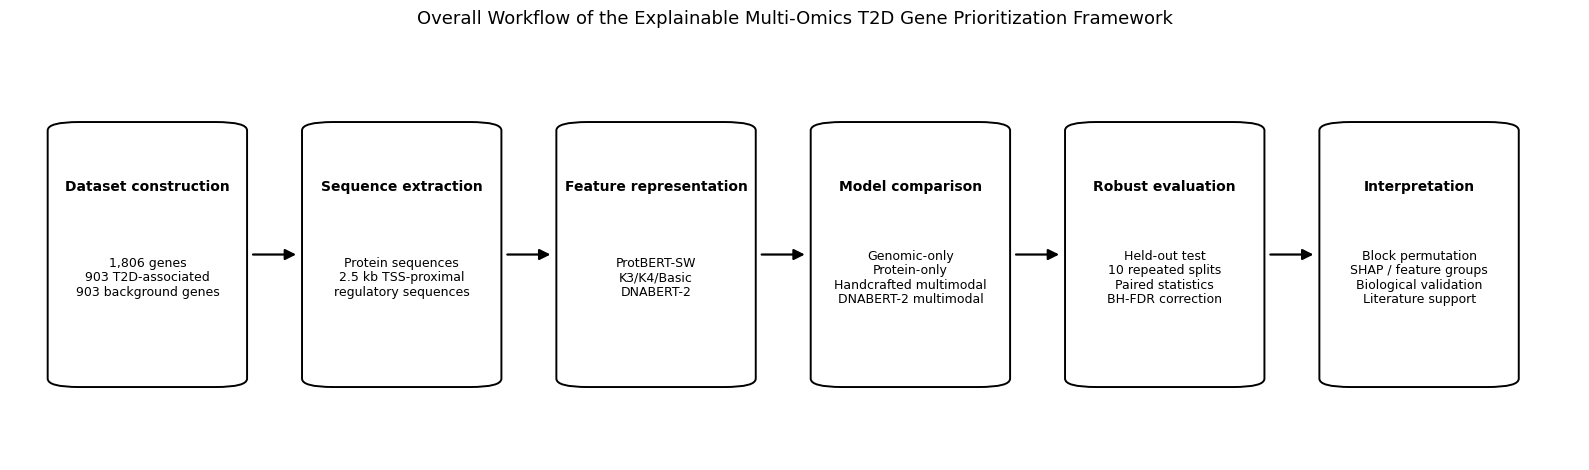

In [8]:
# ============================================================
# FIGURE 1 — OVERALL WORKFLOW DIAGRAM (FIXED)
# ============================================================

workflow_steps = [
    {
        "title": "Dataset construction",
        "body": "1,806 genes\n903 T2D-associated\n903 background genes"
    },
    {
        "title": "Sequence extraction",
        "body": "Protein sequences\n2.5 kb TSS-proximal\nregulatory sequences"
    },
    {
        "title": "Feature representation",
        "body": "ProtBERT-SW\nK3/K4/Basic\nDNABERT-2"
    },
    {
        "title": "Model comparison",
        "body": "Genomic-only\nProtein-only\nHandcrafted multimodal\nDNABERT-2 multimodal"
    },
    {
        "title": "Robust evaluation",
        "body": "Held-out test\n10 repeated splits\nPaired statistics\nBH-FDR correction"
    },
    {
        "title": "Interpretation",
        "body": "Block permutation\nSHAP / feature groups\nBiological validation\nLiterature support"
    }
]

fig, ax = plt.subplots(figsize=(16, 4.8))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.axis("off")

# Layout settings
box_width = 0.115
box_height = 0.62
y = 0.18
x_positions = np.linspace(0.03, 0.84, len(workflow_steps))

# ---- Draw boxes first ----
for x, step in zip(x_positions, workflow_steps):
    box = FancyBboxPatch(
        (x, y),
        box_width,
        box_height,
        boxstyle="round,pad=0.006,rounding_size=0.02",
        linewidth=1.4,
        facecolor="white",
        edgecolor="black",
        zorder=1
    )
    ax.add_patch(box)

    # Title
    ax.text(
        x + box_width / 2,
        y + box_height * 0.76,
        step["title"],
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
        zorder=2
    )

    # Body
    ax.text(
        x + box_width / 2,
        y + box_height * 0.41,
        step["body"],
        ha="center",
        va="center",
        fontsize=9,
        linespacing=1.15,
        zorder=2
    )

# ---- Draw arrows after all boxes ----
for i in range(len(x_positions) - 1):
    x1 = x_positions[i] + box_width + 0.008
    x2 = x_positions[i + 1] - 0.008
    y_mid = y + box_height / 2

    arrow = FancyArrowPatch(
        (x1, y_mid),
        (x2, y_mid),
        arrowstyle="-|>",
        mutation_scale=16,
        linewidth=1.6,
        color="black",
        zorder=5,
        clip_on=False
    )
    ax.add_patch(arrow)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.set_title(
    "Overall Workflow of the Explainable Multi-Omics T2D Gene Prioritization Framework",
    fontsize=13,
    pad=12
)

plt.tight_layout()

out_path = FIGURE_DIR / "fig1_overall_workflow_diagram.png"
save_current_figure(out_path)
plt.show()

Saved: /content/drive/MyDrive/Project_Protein/model/phase16_manuscript_figures_package/figures/fig2_heldout_model_performance_comparison.png


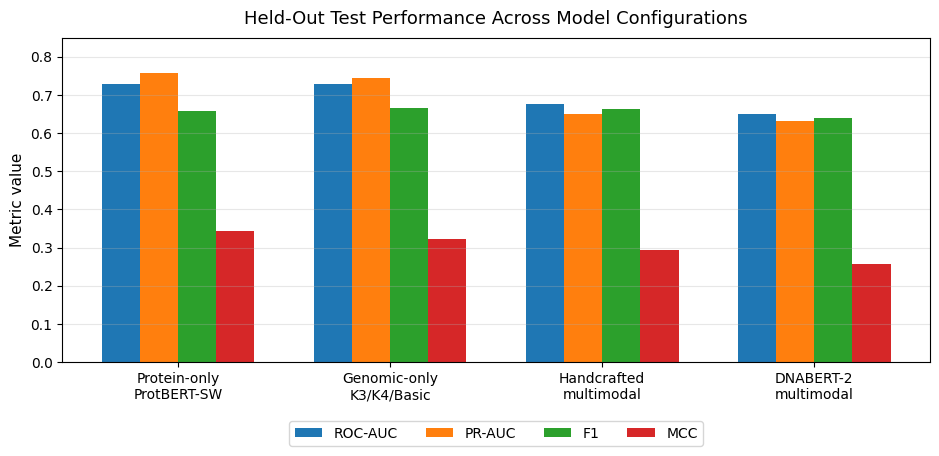

In [9]:
# ============================================================
# FIGURE 2 — HELD-OUT PERFORMANCE COMPARISON (REVISED)
# ============================================================

metrics = ["roc_auc", "pr_auc", "f1", "mcc"]
metric_labels = ["ROC-AUC", "PR-AUC", "F1", "MCC"]

plot_df = heldout_plot_df.copy()

# Use clear configuration-level labels instead of repeated classifier names
# Adjust these labels if your heldout_plot_df has a different row order.
model_labels = [
    "Protein-only\nProtBERT-SW",
    "Genomic-only\nK3/K4/Basic",
    "Handcrafted\nmultimodal",
    "DNABERT-2\nmultimodal"
]

# If plot_df has more than 4 rows, keep only the four manuscript models if possible.
# This prevents old experimental rows from appearing in the paper figure.
if len(plot_df) > 4:
    preferred_names = [
        "Protein-only ProtBERT-SW",
        "Genomic-only K3/K4/Basic",
        "Handcrafted multimodal",
        "DNABERT-2 multimodal"
    ]

    if "config" in plot_df.columns:
        plot_df = plot_df[plot_df["config"].isin(preferred_names)].copy()
    elif "model_config" in plot_df.columns:
        plot_df = plot_df[plot_df["model_config"].isin(preferred_names)].copy()
    elif "setting" in plot_df.columns:
        plot_df = plot_df[plot_df["setting"].isin(preferred_names)].copy()
    else:
        # Fallback: keep the first four rows only if no configuration column exists.
        plot_df = plot_df.head(4).copy()

# Assign clean labels
plot_df["model_display"] = model_labels[:len(plot_df)]

x = np.arange(len(plot_df))
width = 0.18

fig, ax = plt.subplots(figsize=(9.5, 5.2))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

for i, metric in enumerate(metrics):
    ax.bar(
        x + (i - 1.5) * width,
        plot_df[metric],
        width=width,
        label=metric_labels[i]
    )

ax.set_xticks(x)
ax.set_xticklabels(plot_df["model_display"], fontsize=10)
ax.set_ylabel("Metric value", fontsize=11)
ax.set_ylim(0, 0.85)
ax.set_title("Held-Out Test Performance Across Model Configurations", fontsize=13, pad=10)

ax.grid(axis="y", alpha=0.3)
ax.legend(
    ncol=4,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.16),
    frameon=True
)

plt.tight_layout(rect=[0, 0.08, 1, 1])

out_path = FIGURE_DIR / "fig2_heldout_model_performance_comparison.png"
save_current_figure(out_path)
plt.show()

Saved: /content/drive/MyDrive/Project_Protein/model/phase16_manuscript_figures_package/figures/fig3_repeated_split_performance_errorbars.png


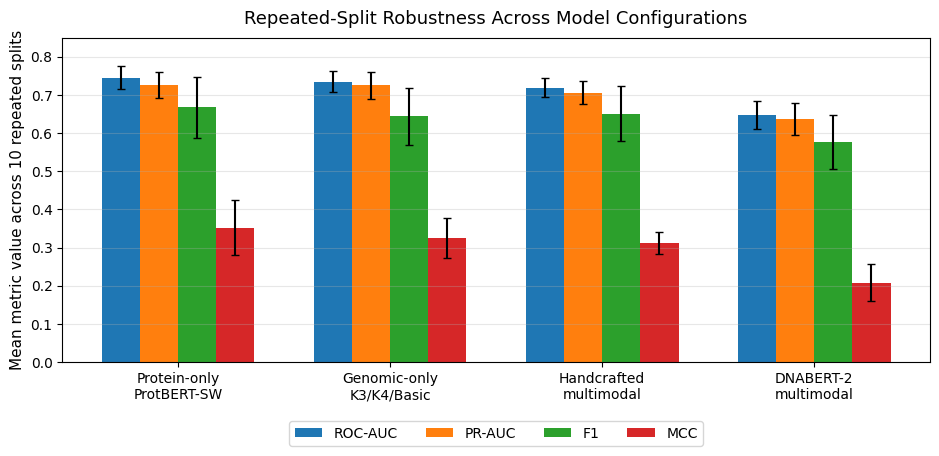

In [10]:
# ============================================================
# FIGURE 3 — REPEATED-SPLIT PERFORMANCE WITH ERROR BARS (REVISED)
# ============================================================

metrics = ["roc_auc", "pr_auc", "f1", "mcc"]
metric_labels = ["ROC-AUC", "PR-AUC", "F1", "MCC"]

plot_df = repeated_plot_df.copy()

# Reset index safely if model names are stored in the index
if "model" not in plot_df.columns:
    plot_df = plot_df.reset_index()
    if "model" not in plot_df.columns and "index" in plot_df.columns:
        plot_df = plot_df.rename(columns={"index": "model"})

# Keep only four manuscript models if old experimental rows exist
preferred_labels = [
    "Protein-only\nProtBERT-SW",
    "Genomic-only\nK3/K4/Basic",
    "Handcrafted\nmultimodal",
    "DNABERT-2\nmultimodal"
]

preferred_names = [
    "Protein-only ProtBERT-SW",
    "Genomic-only K3/K4/Basic",
    "Handcrafted multimodal",
    "DNABERT-2 multimodal"
]

# Try to filter by a configuration/model column if available
candidate_model_cols = [
    c for c in plot_df.columns
    if c.lower() in ["model", "config", "model_config", "setting", "configuration"]
]

if candidate_model_cols:
    model_col = candidate_model_cols[0]

    # If the values match preferred names, filter and order them
    if set(preferred_names).issubset(set(plot_df[model_col].astype(str))):
        plot_df[model_col] = plot_df[model_col].astype(str)
        plot_df = (
            plot_df.set_index(model_col)
            .loc[preferred_names]
            .reset_index()
        )
    else:
        # Fallback: use first four rows
        plot_df = plot_df.head(4).copy()
else:
    plot_df = plot_df.head(4).copy()

# Force clear labels for the paper figure
plot_df["model_display"] = preferred_labels[:len(plot_df)]

x = np.arange(len(plot_df))
width = 0.18

fig, ax = plt.subplots(figsize=(9.5, 5.2))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

for i, metric in enumerate(metrics):
    mean_col = f"{metric}_mean"
    sd_col = f"{metric}_sd"

    if mean_col not in plot_df.columns:
        continue

    yerr = plot_df[sd_col] if sd_col in plot_df.columns else None

    ax.bar(
        x + (i - 1.5) * width,
        plot_df[mean_col],
        yerr=yerr,
        width=width,
        capsize=3,
        label=metric_labels[i]
    )

ax.set_xticks(x)
ax.set_xticklabels(plot_df["model_display"], fontsize=10)
ax.set_ylabel("Mean metric value across 10 repeated splits", fontsize=11)
ax.set_ylim(0, 0.85)
ax.set_title("Repeated-Split Robustness Across Model Configurations", fontsize=13, pad=10)

ax.grid(axis="y", alpha=0.3)
ax.legend(
    ncol=4,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.16),
    frameon=True
)

plt.tight_layout(rect=[0, 0.08, 1, 1])

out_path = FIGURE_DIR / "fig3_repeated_split_performance_errorbars.png"
save_current_figure(out_path)
plt.show()

Saved: /content/drive/MyDrive/Project_Protein/model/phase16_manuscript_figures_package/figures/fig4_paired_delta_dnabert2_vs_handcrafted.png


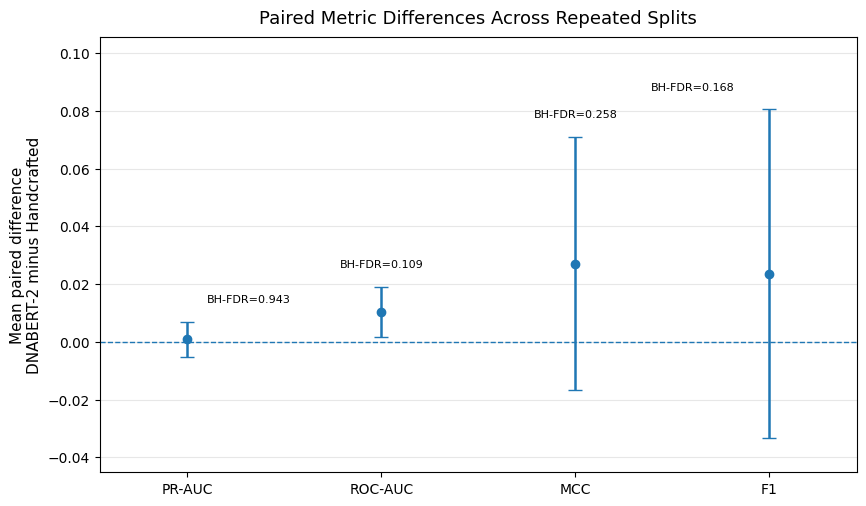

In [11]:
# ============================================================
# FIGURE 4 — PAIRED DELTA PLOT
# DNABERT-2 multimodal minus Handcrafted multimodal
# ============================================================

plot_df = paired_df.copy()

# Normalize columns
if "metric" not in plot_df.columns:
    metric_col = [c for c in plot_df.columns if "metric" in c.lower()]
    if metric_col:
        plot_df = plot_df.rename(columns={metric_col[0]: "metric"})

for old, new in [
    ("delta_mean", "mean_delta"),
    ("mean_difference", "mean_delta"),
    ("ci_lower", "ci_low"),
    ("lower_ci", "ci_low"),
    ("ci_upper", "ci_high"),
    ("upper_ci", "ci_high"),
    ("bh_fdr_p", "bh_fdr"),
    ("fdr", "bh_fdr"),
]:
    if old in plot_df.columns and new not in plot_df.columns:
        plot_df = plot_df.rename(columns={old: new})

required = ["metric", "mean_delta", "ci_low", "ci_high", "bh_fdr"]
if not all(c in plot_df.columns for c in required):
    plot_df = pd.DataFrame([
        {"metric": "PR-AUC", "mean_delta": 0.0009, "ci_low": -0.0053, "ci_high": 0.0070, "bh_fdr": 0.9434},
        {"metric": "MCC", "mean_delta": 0.0271, "ci_low": -0.0167, "ci_high": 0.0709, "bh_fdr": 0.2578},
        {"metric": "ROC-AUC", "mean_delta": 0.0103, "ci_low": 0.0017, "ci_high": 0.0190, "bh_fdr": 0.1094},
        {"metric": "F1", "mean_delta": 0.0236, "ci_low": -0.0332, "ci_high": 0.0805, "bh_fdr": 0.1680},
    ])

plot_df["metric"] = plot_df["metric"].apply(compact_metric_name)

plot_df = (
    plot_df.set_index("metric")
    .loc[["PR-AUC", "ROC-AUC", "MCC", "F1"]]
    .reset_index()
)

x = np.arange(len(plot_df))
y = plot_df["mean_delta"].values
err_low = y - plot_df["ci_low"].values
err_high = plot_df["ci_high"].values - y

fig, ax = plt.subplots(figsize=(8.8, 5.2))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

ax.errorbar(
    x,
    y,
    yerr=[err_low, err_high],
    fmt="o",
    capsize=5,
    linewidth=1.8
)

ax.axhline(0, linestyle="--", linewidth=1)

ax.set_xticks(x)
ax.set_xticklabels(plot_df["metric"], fontsize=10)
ax.set_ylabel("Mean paired difference\nDNABERT-2 minus Handcrafted", fontsize=11)
ax.set_title("Paired Metric Differences Across Repeated Splits", fontsize=13, pad=10)

# Add horizontal margin so side labels do not overflow
ax.set_xlim(-0.45, len(plot_df) - 0.55)

# Add vertical margin for top annotations
y_min = min(plot_df["ci_low"].min() - 0.012, -0.045)
y_max = max(plot_df["ci_high"].max() + 0.025, 0.105)
ax.set_ylim(y_min, y_max)

# Metric-specific annotation offsets
annotation_offsets = {
    "PR-AUC": (0.10, 0.006, "left"),
    "ROC-AUC": (0.00, 0.006, "center"),
    "MCC": (0.00, 0.006, "center"),
    "F1": (-0.18, 0.006, "right"),
}

for i, row in plot_df.iterrows():
    metric = row["metric"]
    dx, dy, ha = annotation_offsets.get(metric, (0.00, 0.006, "center"))
    label = f"BH-FDR={row['bh_fdr']:.3f}"

    ax.text(
        i + dx,
        row["ci_high"] + dy,
        label,
        ha=ha,
        va="bottom",
        fontsize=8,
        clip_on=False
    )

ax.grid(axis="y", alpha=0.3)

plt.tight_layout(pad=1.2)

out_path = FIGURE_DIR / "fig4_paired_delta_dnabert2_vs_handcrafted.png"
save_current_figure(out_path)
plt.show()

Saved: /content/drive/MyDrive/Project_Protein/model/phase16_manuscript_figures_package/figures/fig5_block_level_permutation_importance.png


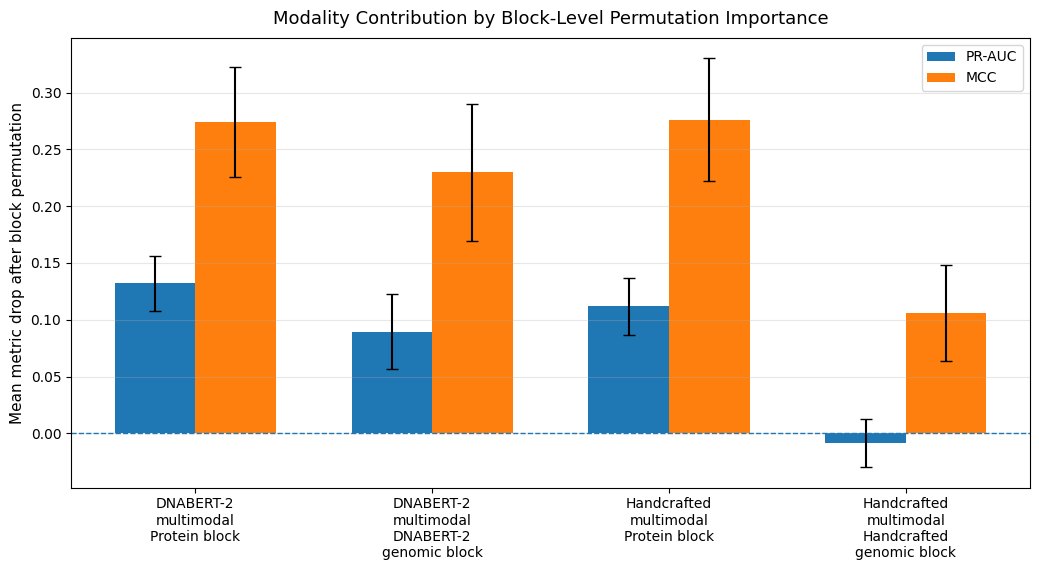

In [12]:
# ============================================================
# FIGURE 5 — BLOCK-LEVEL PERMUTATION IMPORTANCE (REVISED)
# ============================================================

plot_df = block_importance_df.copy()

# -----------------------------
# 1) Keep core metrics only
# -----------------------------
if "metric" in plot_df.columns:
    plot_df["metric_clean"] = plot_df["metric"].astype(str).str.lower()
    plot_df = plot_df[
        plot_df["metric_clean"].isin(["pr_auc", "roc_auc", "mcc", "f1"])
    ].copy()

# -----------------------------
# 2) Clean model labels robustly
# -----------------------------
plot_df["model_display"] = plot_df["model"].astype(str).replace({
    "Handcrafted_multimodal": "Handcrafted\nmultimodal",
    "DNABERT2_multimodal": "DNABERT-2\nmultimodal",
    "DNABERT-2_multimodal": "DNABERT-2\nmultimodal",
    "Handcrafted multimodal": "Handcrafted\nmultimodal",
    "DNABERT2 multimodal": "DNABERT-2\nmultimodal",
})

# -----------------------------
# 3) Clean block labels robustly
# -----------------------------
plot_df["block_display"] = plot_df["block_name"].astype(str).replace({
    "Protein_ProtBERT_SW_block": "Protein block",
    "Genomic_K3K4Basic_block": "Handcrafted\ngenomic block",
    "Genomic_DNABERT2_block": "DNABERT-2\ngenomic block",
    "Protein block": "Protein block",
    "Handcrafted genomic block": "Handcrafted\ngenomic block",
    "DNABERT-2 genomic block": "DNABERT-2\ngenomic block",
})

# -----------------------------
# 4) Metric labels
# -----------------------------
plot_df["metric_display"] = plot_df["metric"].apply(compact_metric_name)

# Keep only two metrics to avoid overcrowding
selected_metrics = ["PR-AUC", "MCC"]
plot_df = plot_df[plot_df["metric_display"].isin(selected_metrics)].copy()

# -----------------------------
# 5) Create combined labels
# -----------------------------
plot_df["label"] = plot_df["model_display"] + "\n" + plot_df["block_display"]

# Fixed manuscript order
preferred_label_order = [
    "DNABERT-2\nmultimodal\nProtein block",
    "DNABERT-2\nmultimodal\nDNABERT-2\ngenomic block",
    "Handcrafted\nmultimodal\nProtein block",
    "Handcrafted\nmultimodal\nHandcrafted\ngenomic block",
]

# Keep only labels that actually exist in the dataframe
labels = [lab for lab in preferred_label_order if lab in plot_df["label"].unique()]

# Fallback if labels do not match exactly
if not labels:
    labels = plot_df["label"].drop_duplicates().tolist()

metric_order = selected_metrics
x = np.arange(len(labels))
width = 0.34

# -----------------------------
# 6) Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(10.5, 5.8))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

for i, metric in enumerate(metric_order):
    sub = plot_df[plot_df["metric_display"] == metric].copy()

    values = []
    errors = []

    for label in labels:
        row = sub[sub["label"] == label]
        if row.empty:
            values.append(0.0)
            errors.append(0.0)
        else:
            values.append(float(row["mean_drop"].iloc[0]))
            errors.append(float(row["sd_drop"].iloc[0]) if "sd_drop" in row.columns else 0.0)

    ax.bar(
        x + (i - 0.5) * width,
        values,
        yerr=errors,
        width=width,
        capsize=4,
        label=metric
    )

# -----------------------------
# 7) Formatting
# -----------------------------
ax.axhline(0, linestyle="--", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel("Mean metric drop after block permutation", fontsize=11)
ax.set_title("Modality Contribution by Block-Level Permutation Importance", fontsize=13, pad=10)

ax.grid(axis="y", alpha=0.3)
ax.legend(loc="upper right", frameon=True)

plt.tight_layout()

out_path = FIGURE_DIR / "fig5_block_level_permutation_importance.png"
save_current_figure(out_path)
plt.show()

Saved: figures/fig6_candidate_gene_pathway_heatmap_no_SCD5.png


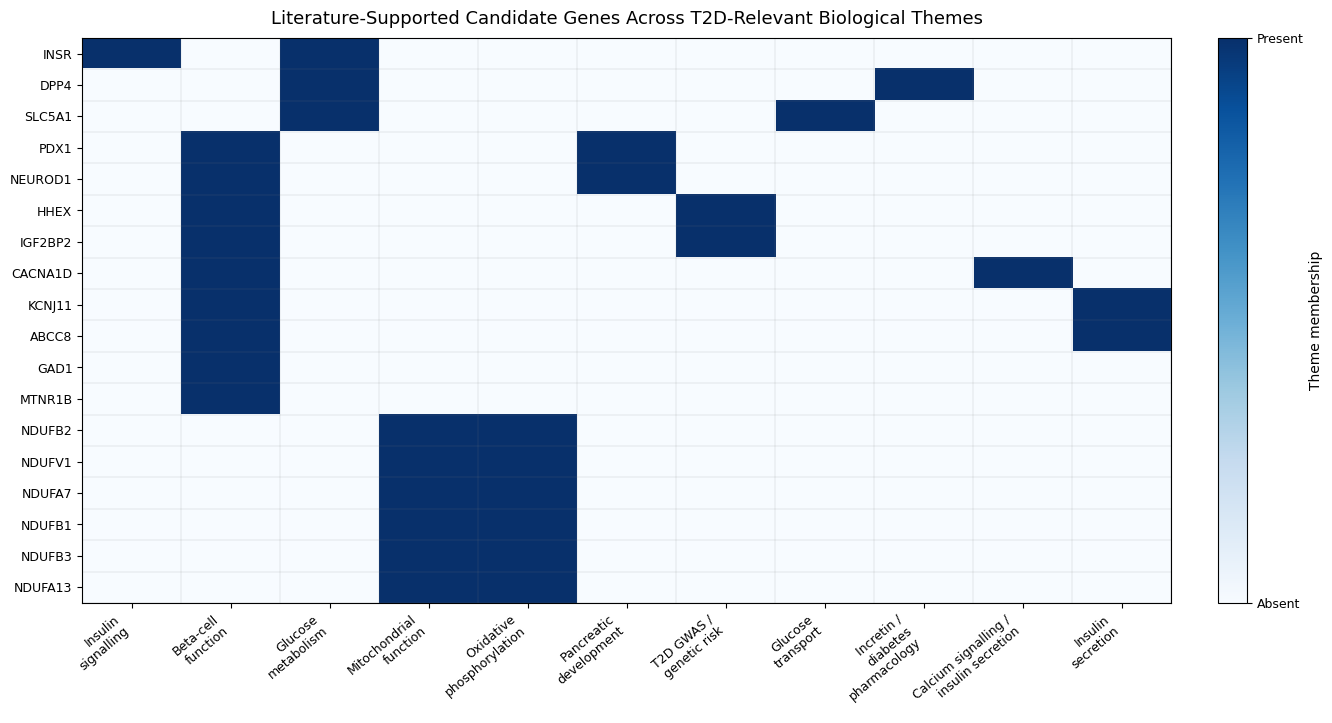

Saved heatmap table: figures/fig6_candidate_gene_pathway_heatmap_no_SCD5_table.csv

Genes included in revised Figure 6:
['INSR', 'DPP4', 'SLC5A1', 'PDX1', 'NEUROD1', 'HHEX', 'IGF2BP2', 'CACNA1D', 'KCNJ11', 'ABCC8', 'GAD1', 'MTNR1B', 'NDUFB2', 'NDUFV1', 'NDUFA7', 'NDUFB1', 'NDUFB3', 'NDUFA13']


In [13]:
# ============================================================
# FIGURE 6 — CANDIDATE GENE x PATHWAY HEATMAP (NO SCD5)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import textwrap
from pathlib import Path

# ------------------------------------------------------------------
# 0) CONFIG
# ------------------------------------------------------------------
# Nếu bạn đã có FIGURE_DIR từ trước thì có thể bỏ 2 dòng dưới
FIGURE_DIR = Path("./figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------------
# 1) HELPER FUNCTIONS
# ------------------------------------------------------------------
def wrap_label(text, width=14):
    """Wrap text for cleaner axis labels."""
    if pd.isna(text):
        return ""
    return "\n".join(textwrap.wrap(str(text), width=width))

def save_current_figure(out_path, dpi=300):
    """Save current matplotlib figure safely."""
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_path, dpi=dpi, bbox_inches="tight", facecolor="white")
    print("Saved:", out_path)

# ------------------------------------------------------------------
# 2) CHECK INPUT
# ------------------------------------------------------------------
# Yêu cầu: pathway_matrix_df phải tồn tại và có:
# - 1 cột tên "gene"
# - các cột còn lại là theme/pathway membership dạng 0/1
#
# Ví dụ structure:
# gene | Insulin signalling | Beta-cell function | ...
#
# Nếu tên biến của bạn khác, hãy đổi lại cho đúng.

if "pathway_matrix_df" not in globals():
    raise ValueError(
        "Không tìm thấy biến 'pathway_matrix_df'. "
        "Hãy chắc chắn rằng dataframe này đã được tạo trước đó."
    )

if pathway_matrix_df is None or pathway_matrix_df.empty:
    raise ValueError("pathway_matrix_df đang rỗng hoặc None.")

if "gene" not in pathway_matrix_df.columns:
    raise ValueError("pathway_matrix_df phải có cột 'gene'.")

# ------------------------------------------------------------------
# 3) PREPARE HEATMAP DATA
# ------------------------------------------------------------------
# Lấy toàn bộ cột pathway (trừ cột gene)
pathway_cols = [c for c in pathway_matrix_df.columns if c != "gene"]

# Tạo heatmap dataframe
heatmap_df = pathway_matrix_df.set_index("gene")[pathway_cols].copy()

# Ép về numeric nếu cần
for c in heatmap_df.columns:
    heatmap_df[c] = pd.to_numeric(heatmap_df[c], errors="coerce").fillna(0)

# ------------------------------------------------
# QUAN TRỌNG: LOẠI SCD5 KHỎI FIGURE
# ------------------------------------------------
heatmap_df = heatmap_df.loc[heatmap_df.index != "SCD5"]

# Giữ lại chỉ các pathway có ít nhất 1 gene
heatmap_df = heatmap_df.loc[:, heatmap_df.sum(axis=0) > 0]

# Tùy chọn: bỏ các gene không thuộc pathway nào
heatmap_df = heatmap_df.loc[heatmap_df.sum(axis=1) > 0]

if heatmap_df.empty:
    raise ValueError("Sau khi lọc (bao gồm bỏ SCD5), heatmap_df bị rỗng.")

# ------------------------------------------------------------------
# 4) ORDER GENES (BIOLOGICALLY MEANINGFUL ORDER)
# ------------------------------------------------------------------
preferred_gene_order = [
    # insulin / glucose-related
    "INSR", "DPP4", "SLC5A1",

    # pancreatic development / beta-cell regulatory genes
    "PDX1", "NEUROD1", "HHEX", "IGF2BP2", "CACNA1D",

    # insulin secretion / beta-cell excitability
    "KCNJ11", "ABCC8", "GAD1", "MTNR1B",

    # mitochondrial / OXPHOS-related genes
    "NDUFB2", "NDUFV1", "NDUFA7", "NDUFB1", "NDUFB3", "NDUFA13"
]

existing_order = [g for g in preferred_gene_order if g in heatmap_df.index]
remaining_genes = [g for g in heatmap_df.index if g not in existing_order]

# Có thể sort alphabetically cho phần còn lại để ổn định
remaining_genes = sorted(remaining_genes)

heatmap_df = heatmap_df.loc[existing_order + remaining_genes]

# ------------------------------------------------------------------
# 5) FRIENDLY LABELS FOR PATHWAYS
# ------------------------------------------------------------------
pathway_label_map = {
    "Insulin signalling": "Insulin\nsignalling",
    "Beta-cell function": "Beta-cell\nfunction",
    "Glucose metabolism": "Glucose\nmetabolism",
    "Mitochondrial function": "Mitochondrial\nfunction",
    "Oxidative phosphorylation": "Oxidative\nphosphorylation",
    "Pancreatic development": "Pancreatic\ndevelopment",
    "T2D GWAS / genetic risk": "T2D GWAS /\ngenetic risk",
    "T2D GWAS/genetic risk": "T2D GWAS /\ngenetic risk",
    "Glucose transport": "Glucose\ntransport",
    "Incretin signalling / diabetes pharmacology": "Incretin /\ndiabetes\npharmacology",
    "Calcium signalling / insulin secretion": "Calcium signalling /\ninsulin secretion",
    "Insulin secretion": "Insulin\nsecretion",
    "Lipid metabolism": "Lipid\nmetabolism",
}

x_labels = [pathway_label_map.get(c, wrap_label(c, 14)) for c in heatmap_df.columns]

# ------------------------------------------------------------------
# 6) PLOT FIGURE
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(13.5, 8.0))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

im = ax.imshow(
    heatmap_df.values,
    aspect="auto",
    interpolation="nearest",
    vmin=0,
    vmax=1,
    cmap="Blues"
)

# Axis ticks
ax.set_xticks(np.arange(heatmap_df.shape[1]))
ax.set_xticklabels(
    x_labels,
    rotation=40,
    ha="right",
    fontsize=9
)

ax.set_yticks(np.arange(heatmap_df.shape[0]))
ax.set_yticklabels(heatmap_df.index, fontsize=9)

# Title
ax.set_title(
    "Literature-Supported Candidate Genes Across T2D-Relevant Biological Themes",
    fontsize=13,
    pad=10
)

# Gridlines between cells
ax.set_xticks(np.arange(-0.5, heatmap_df.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-0.5, heatmap_df.shape[0], 1), minor=True)
ax.grid(which="minor", linewidth=0.35, alpha=0.35, color="gray")
ax.tick_params(which="minor", bottom=False, left=False)

# Colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.04)
cbar.set_label("Theme membership", fontsize=10)
cbar.ax.tick_params(labelsize=9)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(["Absent", "Present"])

# Layout
plt.tight_layout()
plt.subplots_adjust(bottom=0.24)

# Save
out_path = FIGURE_DIR / "fig6_candidate_gene_pathway_heatmap_no_SCD5.png"
save_current_figure(out_path)

plt.show()

# ------------------------------------------------------------------
# 7) OPTIONAL: EXPORT THE EXACT TABLE USED FOR FIGURE 6
# ------------------------------------------------------------------
heatmap_table_path = FIGURE_DIR / "fig6_candidate_gene_pathway_heatmap_no_SCD5_table.csv"
heatmap_df.reset_index().rename(columns={"index": "gene"}).to_csv(heatmap_table_path, index=False)
print("Saved heatmap table:", heatmap_table_path)

# Quick confirmation
print("\nGenes included in revised Figure 6:")
print(list(heatmap_df.index))

Saved: figures/fig7_biological_pathway_summary_barplot.png


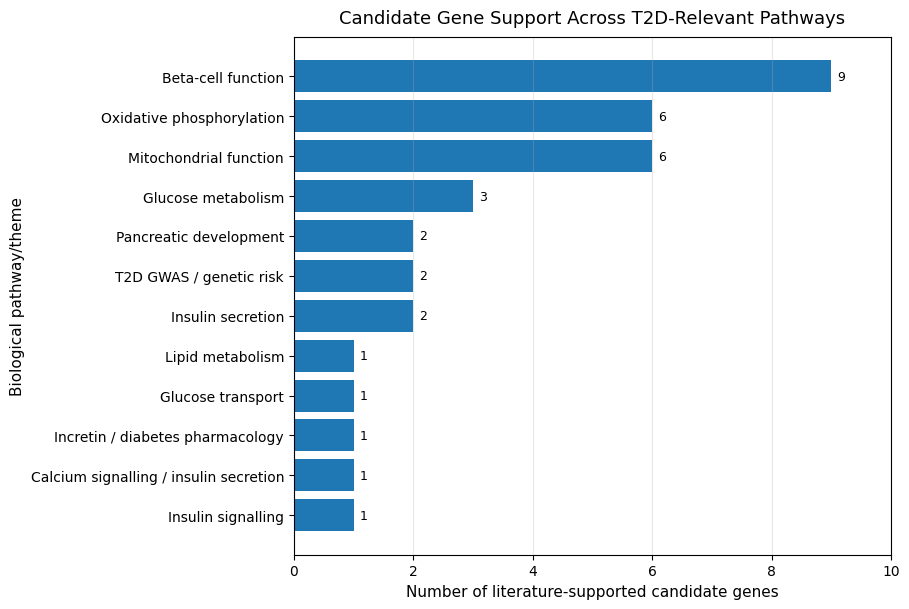

In [14]:
# ============================================================
# FIGURE 7 — BIOLOGICAL PATHWAY SUMMARY BAR PLOT (REVISED)
# ============================================================

plot_df = pathway_summary_df.copy()
plot_df = plot_df[plot_df["n_candidate_genes"] > 0].copy()

# Shorten long pathway labels for paper-friendly display
pathway_label_map = {
    "Insulin signalling": "Insulin signalling",
    "Beta-cell function": "Beta-cell function",
    "Glucose metabolism": "Glucose metabolism",
    "Mitochondrial function": "Mitochondrial function",
    "Oxidative phosphorylation": "Oxidative phosphorylation",
    "Pancreatic development": "Pancreatic development",
    "T2D GWAS / genetic risk": "T2D GWAS / genetic risk",
    "T2D GWAS/genetic risk": "T2D GWAS / genetic risk",
    "Glucose transport": "Glucose transport",
    "Incretin signalling / diabetes pharmacology": "Incretin / diabetes pharmacology",
    "Calcium signalling / insulin secretion": "Calcium signalling / insulin secretion",
    "Insulin secretion": "Insulin secretion",
    "Lipid metabolism": "Lipid metabolism",
}

plot_df["pathway_display"] = plot_df["pathway_group"].astype(str).replace(pathway_label_map)

# Sort ascending so the largest bar appears at the top after barh plotting
plot_df = plot_df.sort_values("n_candidate_genes", ascending=True)

fig, ax = plt.subplots(figsize=(9.2, 6.2))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

bars = ax.barh(
    plot_df["pathway_display"],
    plot_df["n_candidate_genes"]
)

ax.set_xlabel("Number of literature-supported candidate genes", fontsize=11)
ax.set_ylabel("Biological pathway/theme", fontsize=11)
ax.set_title("Candidate Gene Support Across T2D-Relevant Pathways", fontsize=13, pad=10)

ax.grid(axis="x", alpha=0.3)

# Add count labels at the end of each bar
max_count = plot_df["n_candidate_genes"].max()
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.10,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width)}",
        va="center",
        ha="left",
        fontsize=9
    )

ax.set_xlim(0, max_count + 1.0)
ax.tick_params(axis="y", labelsize=10)
ax.tick_params(axis="x", labelsize=10)

plt.tight_layout()

out_path = FIGURE_DIR / "fig7_biological_pathway_summary_barplot.png"
save_current_figure(out_path)
plt.show()

Saved: /content/drive/MyDrive/Project_Protein/model/phase16_manuscript_figures_package/results/phase16_biological_validation_summary_table.csv
Saved: figures/fig8_biological_validation_random_baseline_summary.png


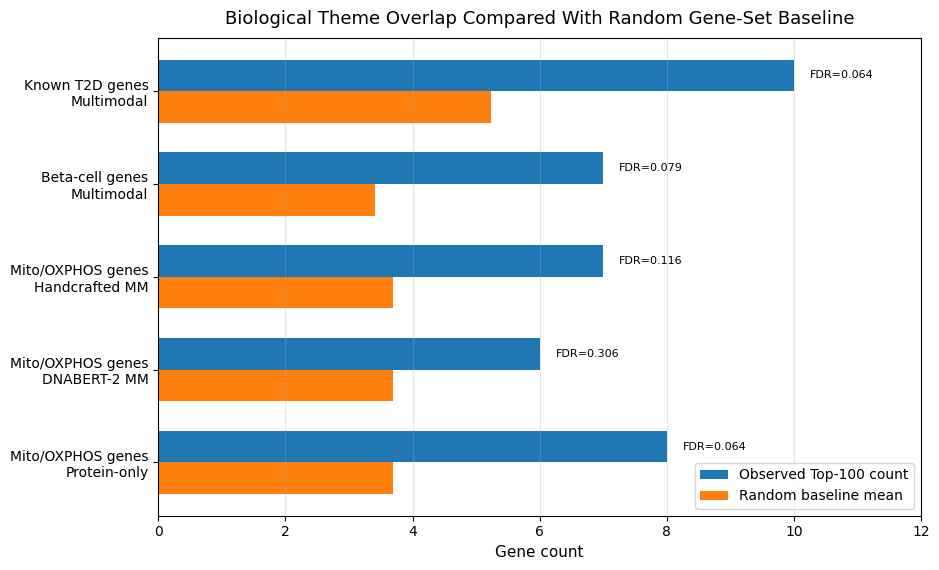

In [15]:
# ============================================================
# FIGURE 8 — BIOLOGICAL VALIDATION SUMMARY PLOT (REVISED)
# ============================================================
# Horizontal grouped bar chart for better readability in manuscript.
# ============================================================

bio_summary_records = [
    {
        "theme": "Known T2D genes",
        "observed_top100": 10,
        "random_mean": 5.241,
        "fdr": 0.064,
        "model_group": "Multimodal"
    },
    {
        "theme": "Beta-cell genes",
        "observed_top100": 7,
        "random_mean": 3.413,
        "fdr": 0.0791,
        "model_group": "Multimodal"
    },
    {
        "theme": "Mito/OXPHOS genes",
        "observed_top100": 7,
        "random_mean": 3.694,
        "fdr": 0.1158,
        "model_group": "Handcrafted multimodal"
    },
    {
        "theme": "Mito/OXPHOS genes",
        "observed_top100": 6,
        "random_mean": 3.694,
        "fdr": 0.3058,
        "model_group": "DNABERT-2 multimodal"
    },
    {
        "theme": "Mito/OXPHOS genes",
        "observed_top100": 8,
        "random_mean": 3.694,
        "fdr": 0.064,
        "model_group": "Protein-only"
    },
]

bio_summary_df = pd.DataFrame(bio_summary_records)

save_df(
    bio_summary_df,
    RESULT_DIR / "phase16_biological_validation_summary_table.csv"
)

plot_df = bio_summary_df.copy()

# Paper-friendly labels
theme_label_map = {
    "Known T2D genes": "Known T2D genes",
    "Beta-cell genes": "Beta-cell genes",
    "Mito/OXPHOS genes": "Mito/OXPHOS genes",
}

model_label_map = {
    "Multimodal": "Multimodal",
    "Handcrafted multimodal": "Handcrafted MM",
    "DNABERT-2 multimodal": "DNABERT-2 MM",
    "Protein-only": "Protein-only",
}

plot_df["theme_display"] = plot_df["theme"].replace(theme_label_map)
plot_df["model_display"] = plot_df["model_group"].replace(model_label_map)
plot_df["label"] = plot_df["theme_display"] + "\n" + plot_df["model_display"]

# Reverse order so first item appears at the top
plot_df = plot_df.iloc[::-1].reset_index(drop=True)

y = np.arange(len(plot_df))
height = 0.34

fig, ax = plt.subplots(figsize=(9.5, 5.8))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

ax.barh(
    y + height / 2,
    plot_df["observed_top100"],
    height=height,
    label="Observed Top-100 count"
)

ax.barh(
    y - height / 2,
    plot_df["random_mean"],
    height=height,
    label="Random baseline mean"
)

ax.set_yticks(y)
ax.set_yticklabels(plot_df["label"], fontsize=10)

ax.set_xlabel("Gene count", fontsize=11)
ax.set_title(
    "Biological Theme Overlap Compared With Random Gene-Set Baseline",
    fontsize=13,
    pad=10
)

ax.grid(axis="x", alpha=0.3)
ax.legend(loc="lower right", frameon=True)

# Add FDR labels to the right of the observed bars
max_x = max(plot_df["observed_top100"].max(), plot_df["random_mean"].max())

for i, row in plot_df.iterrows():
    x_pos = max(row["observed_top100"], row["random_mean"]) + 0.25
    ax.text(
        x_pos,
        i + height / 2,
        f"FDR={row['fdr']:.3f}",
        va="center",
        ha="left",
        fontsize=8
    )

ax.set_xlim(0, max_x + 2.0)

plt.tight_layout()

out_path = FIGURE_DIR / "fig8_biological_validation_random_baseline_summary.png"
save_current_figure(out_path)
plt.show()

Saved: figures/fig9_exploratory_genomic_feature_group_importance.png


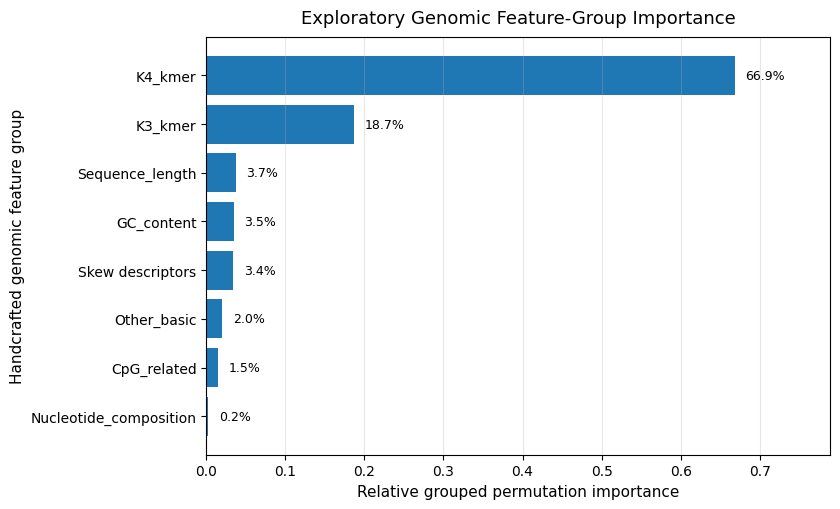

In [16]:
# ============================================================
# OPTIONAL FIGURE 9 — GENOMIC FEATURE-GROUP EXPLAINABILITY (REVISED)
# ============================================================
# Use as supplementary unless professor wants more XAI figures.
# Mapping confidence from Phase 14C was low/assumed, so this
# figure should be labelled exploratory.
# ============================================================

if group_perm_df is not None and not group_perm_df.empty:
    plot_df = group_perm_df.copy()

    if "relative_group_importance" in plot_df.columns:
        value_col = "relative_group_importance"
        xlabel = "Relative grouped permutation importance"
        is_relative = True
    else:
        value_col = "sum_importance"
        xlabel = "Sum permutation importance"
        is_relative = False

    # Clean group labels
    feature_group_label_map = {
        "K4": "K4 k-mers",
        "K3": "K3 k-mers",
        "Basic": "Basic composition",
        "GC_CpG": "GC/CpG features",
        "GC/CpG": "GC/CpG features",
        "Skew": "Skew descriptors",
        "Other": "Other features",
    }

    plot_df["feature_group_display"] = (
        plot_df["feature_group"]
        .astype(str)
        .replace(feature_group_label_map)
    )

    plot_df = plot_df.sort_values(value_col, ascending=True)

    fig, ax = plt.subplots(figsize=(8.5, 5.2))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    bars = ax.barh(
        plot_df["feature_group_display"],
        plot_df[value_col]
    )

    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel("Handcrafted genomic feature group", fontsize=11)
    ax.set_title(
        "Exploratory Genomic Feature-Group Importance",
        fontsize=13,
        pad=10
    )

    ax.grid(axis="x", alpha=0.3)
    ax.tick_params(axis="y", labelsize=10)
    ax.tick_params(axis="x", labelsize=10)

    max_value = float(plot_df[value_col].max())

    # Add value labels
    for bar in bars:
        width = bar.get_width()

        if is_relative:
            label = f"{width:.1%}" if width <= 1 else f"{width:.1f}%"
        else:
            label = f"{width:.3f}"

        ax.text(
            width + max_value * 0.02,
            bar.get_y() + bar.get_height() / 2,
            label,
            va="center",
            ha="left",
            fontsize=9
        )

    ax.set_xlim(0, max_value * 1.18)

    plt.tight_layout()

    out_path = FIGURE_DIR / "fig9_exploratory_genomic_feature_group_importance.png"
    save_current_figure(out_path)
    plt.show()

else:
    print("No grouped genomic permutation table found. Figure 9 not generated.")

In [17]:
# ============================================================
# MANUSCRIPT FIGURE INDEX TABLE
# ============================================================

figure_records = [
    {
        "figure_id": "Figure 1",
        "file_name": "fig1_overall_workflow_diagram.png",
        "title": "Overall workflow",
        "recommended_section": "Materials and Methods",
        "main_or_supplementary": "Main",
        "purpose": "Summarizes dataset construction, feature extraction, model evaluation, explainability and biological validation."
    },
    {
        "figure_id": "Figure 2",
        "file_name": "fig2_heldout_model_performance_comparison.png",
        "title": "Held-out performance comparison",
        "recommended_section": "Results",
        "main_or_supplementary": "Main",
        "purpose": "Replaces large held-out performance table with visual comparison across ROC-AUC, PR-AUC, F1 and MCC."
    },
    {
        "figure_id": "Figure 3",
        "file_name": "fig3_repeated_split_performance_errorbars.png",
        "title": "Repeated-split robustness",
        "recommended_section": "Results",
        "main_or_supplementary": "Main or Supplementary",
        "purpose": "Shows robustness across 10 repeated splits using mean and standard deviation."
    },
    {
        "figure_id": "Figure 4",
        "file_name": "fig4_paired_delta_dnabert2_vs_handcrafted.png",
        "title": "Paired DNABERT-2 versus handcrafted delta",
        "recommended_section": "Results",
        "main_or_supplementary": "Main",
        "purpose": "Visualizes calibrated paired statistical comparison and avoids overclaiming DNABERT-2 superiority."
    },
    {
        "figure_id": "Figure 5",
        "file_name": "fig5_block_level_permutation_importance.png",
        "title": "Modality contribution by block permutation",
        "recommended_section": "Results / Explainability",
        "main_or_supplementary": "Main",
        "purpose": "Supports explainability claim and shows protein-dominant but complementary genomic contribution."
    },
    {
        "figure_id": "Figure 6",
        "file_name": "fig6_candidate_gene_pathway_heatmap.png",
        "title": "Candidate gene x biological theme matrix",
        "recommended_section": "Results / Biological validation",
        "main_or_supplementary": "Main",
        "purpose": "Strengthens biological interpretation of candidate genes across T2D-relevant mechanisms."
    },
    {
        "figure_id": "Figure 7",
        "file_name": "fig7_biological_pathway_summary_barplot.png",
        "title": "Biological pathway summary",
        "recommended_section": "Results / Biological validation",
        "main_or_supplementary": "Supplementary or Main",
        "purpose": "Summarizes number of candidate genes per pathway/theme."
    },
    {
        "figure_id": "Figure 8",
        "file_name": "fig8_biological_validation_random_baseline_summary.png",
        "title": "Biological theme overlap versus random baseline",
        "recommended_section": "Results / Biological validation",
        "main_or_supplementary": "Main",
        "purpose": "Shows observed theme overlap compared with random baseline and FDR-calibrated interpretation."
    },
    {
        "figure_id": "Supplementary Figure S1",
        "file_name": "fig9_exploratory_genomic_feature_group_importance.png",
        "title": "Exploratory genomic feature-group importance",
        "recommended_section": "Supplementary / Explainability",
        "main_or_supplementary": "Supplementary",
        "purpose": "Shows exploratory SHAP/permutation feature-group contribution with caveat about reconstructed feature mapping."
    },
]

figure_index_df = pd.DataFrame(figure_records)

display(figure_index_df)

save_df(
    figure_index_df,
    RESULT_DIR / "phase16_manuscript_figure_index.csv"
)

,figure_id,file_name,title,recommended_section,main_or_supplementary,purpose
0,Figure 1,fig1_overall_workflow_diagram.png,Overall workflow,Materials and Methods,Main,"Summarizes dataset construction, feature extraction, model evaluation, explainability and biological validation."
1,Figure 2,fig2_heldout_model_performance_comparison.png,Held-out performance comparison,Results,Main,"Replaces large held-out performance table with visual comparison across ROC-AUC, PR-AUC, F1 and MCC."
2,Figure 3,fig3_repeated_split_performance_errorbars.png,Repeated-split robustness,Results,Main or Supplementary,Shows robustness across 10 repeated splits using mean and standard deviation.
3,Figure 4,fig4_paired_delta_dnabert2_vs_handcrafted.png,Paired DNABERT-2 versus handcrafted delta,Results,Main,Visualizes calibrated paired statistical comparison and avoids overclaiming DNABERT-2 superiority.
4,Figure 5,fig5_block_level_permutation_importance.png,Modality contribution by block permutation,Results / Explainability,Main,Supports explainability claim and shows protein-dominant but complementary genomic contribution.
5,Figure 6,fig6_candidate_gene_pathway_heatmap.png,Candidate gene x biological theme matrix,Results / Biological validation,Main,Strengthens biological interpretation of candidate genes across T2D-relevant mechanisms.
6,Figure 7,fig7_biological_pathway_summary_barplot.png,Biological pathway summary,Results / Biological validation,Supplementary or Main,Summarizes number of candidate genes per pathway/theme.
7,Figure 8,fig8_biological_validation_random_baseline_summary.png,Biological theme overlap versus random baseline,Results / Biological validation,Main,Shows observed theme overlap compared with random baseline and FDR-calibrated interpretation.
8,Supplementary Figure S1,fig9_exploratory_genomic_feature_group_importance.png,Exploratory genomic feature-group importance,Supplementary / Explainability,Supplementary,Shows exploratory SHAP/permutation feature-group contribution with caveat about reconstructed feature mapping.


Saved: /content/drive/MyDrive/Project_Protein/model/phase16_manuscript_figures_package/results/phase16_manuscript_figure_index.csv


In [18]:
# ============================================================
# LATEX FIGURE SNIPPETS
# ============================================================

latex_snippets = r"""
% =========================
% Figure 1: Overall workflow
% =========================
\begin{figure*}[htbp]
\centering
\includegraphics[width=\textwidth]{figures/fig1_overall_workflow_diagram.png}
\caption{Overall workflow of the proposed explainable multi-omics framework for Type 2 Diabetes gene/protein prioritization. The framework integrates dataset construction, sequence extraction, protein and genomic feature representation, model comparison, robustness evaluation, explainability analysis and biological validation.}
\label{fig:workflow}
\end{figure*}

% =========================
% Figure 2: Held-out performance
% =========================
\begin{figure}[htbp]
\centering
\includegraphics[width=\linewidth]{figures/fig2_heldout_model_performance_comparison.png}
\caption{Held-out test performance across model configurations. Protein-based and multimodal models outperformed the genomic-only baseline, while DNABERT-2 achieved the highest ROC-AUC and handcrafted multimodal features achieved the strongest PR-AUC in the held-out comparison.}
\label{fig:heldout_performance}
\end{figure}

% =========================
% Figure 3: Repeated split robustness
% =========================
\begin{figure}[htbp]
\centering
\includegraphics[width=\linewidth]{figures/fig3_repeated_split_performance_errorbars.png}
\caption{Repeated-split robustness across 10 stratified train/validation/test splits. Bars represent mean performance and error bars represent standard deviation across seeds.}
\label{fig:repeated_split}
\end{figure}

% =========================
% Figure 4: Paired delta
% =========================
\begin{figure}[htbp]
\centering
\includegraphics[width=\linewidth]{figures/fig4_paired_delta_dnabert2_vs_handcrafted.png}
\caption{Paired metric differences between DNABERT-2 multimodal and handcrafted multimodal models across repeated splits. Positive values favour DNABERT-2. Benjamini--Hochberg adjusted values indicate that the observed differences did not establish statistically significant superiority after multiple-testing correction.}
\label{fig:paired_delta}
\end{figure}

% =========================
% Figure 5: Modality contribution
% =========================
\begin{figure}[htbp]
\centering
\includegraphics[width=\linewidth]{figures/fig5_block_level_permutation_importance.png}
\caption{Block-level permutation importance for multimodal models. The protein and genomic feature blocks were permuted separately on the held-out test set, and larger metric drops indicate stronger model dependence on the corresponding modality.}
\label{fig:block_importance}
\end{figure}

% =========================
% Figure 6: Candidate gene pathway heatmap
% =========================
\begin{figure*}[htbp]
\centering
\includegraphics[width=\textwidth]{figures/fig6_candidate_gene_pathway_heatmap.png}
\caption{Literature-supported candidate genes across T2D-relevant biological themes. Candidate genes were grouped into insulin signalling, beta-cell function, glucose metabolism, mitochondrial function, oxidative phosphorylation and related mechanisms.}
\label{fig:candidate_pathway_heatmap}
\end{figure*}

% =========================
% Figure 8: Biological validation baseline
% =========================
\begin{figure}[htbp]
\centering
\includegraphics[width=\linewidth]{figures/fig8_biological_validation_random_baseline_summary.png}
\caption{Biological theme overlap compared with random gene-set baselines. Observed top-ranked gene counts are shown against random expectation, with FDR-adjusted values reported above each comparison.}
\label{fig:bio_random_baseline}
\end{figure}
""".strip()

latex_path = REPORT_DIR / "phase16_latex_figure_snippets.tex"
with open(latex_path, "w") as f:
    f.write(latex_snippets)

print("Saved LaTeX snippets:", latex_path)
print(latex_snippets)

Saved LaTeX snippets: /content/drive/MyDrive/Project_Protein/model/phase16_manuscript_figures_package/reports/phase16_latex_figure_snippets.tex
% =========================
% Figure 1: Overall workflow
% =========================
\begin{figure*}[htbp]
\centering
\includegraphics[width=\textwidth]{figures/fig1_overall_workflow_diagram.png}
\caption{Overall workflow of the proposed explainable multi-omics framework for Type 2 Diabetes gene/protein prioritization. The framework integrates dataset construction, sequence extraction, protein and genomic feature representation, model comparison, robustness evaluation, explainability analysis and biological validation.}
\label{fig:workflow}
\end{figure*}

% =========================
% Figure 2: Held-out performance
% =========================
\begin{figure}[htbp]
\centering
\includegraphics[width=\linewidth]{figures/fig2_heldout_model_performance_comparison.png}
\caption{Held-out test performance across model configurations. Protein-based and m

In [19]:
# ============================================================
# EXPORT EXCEL WORKBOOK
# ============================================================

excel_path = EXCEL_DIR / "phase16_manuscript_figures_package_tables.xlsx"

tables = {
    "Figure_Index": figure_index_df,
    "Heldout_Performance": heldout_plot_df,
    "Repeated_Split": repeated_plot_df,
    "Paired_Stats": paired_df,
    "Block_Importance": block_importance_df,
    "Pathway_Summary": pathway_summary_df,
    "Bio_Random_Baseline": bio_summary_df,
}

if group_perm_df is not None:
    tables["Genomic_Group_Perm"] = group_perm_df

if group_shap_df is not None:
    tables["Genomic_Group_SHAP"] = group_shap_df

if pathway_matrix_df is not None:
    tables["Pathway_Matrix"] = pathway_matrix_df

if gene_evidence_df is not None:
    tables["Gene_Evidence"] = gene_evidence_df

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    for sheet_name, df in tables.items():
        if df is not None and not df.empty:
            df.to_excel(writer, sheet_name=sheet_name[:31], index=False)

print("Saved Excel:", excel_path)

Saved Excel: /content/drive/MyDrive/Project_Protein/model/phase16_manuscript_figures_package/excel/phase16_manuscript_figures_package_tables.xlsx


In [20]:
# ============================================================
# MANUSCRIPT FIGURE CAPTIONS AND NOTES
# ============================================================

caption_records = [
    {
        "figure": "Figure 1",
        "caption": "Overall workflow of the proposed explainable multi-omics framework for Type 2 Diabetes gene/protein prioritization. The framework integrates dataset construction, sequence extraction, protein and genomic feature representation, model comparison, robustness evaluation, explainability analysis and biological validation."
    },
    {
        "figure": "Figure 2",
        "caption": "Held-out test performance across model configurations. Protein-based and multimodal models outperformed the genomic-only baseline, while DNABERT-2 achieved the highest ROC-AUC and handcrafted multimodal features achieved the strongest PR-AUC in the held-out comparison."
    },
    {
        "figure": "Figure 3",
        "caption": "Repeated-split robustness across 10 stratified train/validation/test splits. Bars represent mean performance and error bars represent standard deviation across seeds."
    },
    {
        "figure": "Figure 4",
        "caption": "Paired metric differences between DNABERT-2 multimodal and handcrafted multimodal models across repeated splits. Positive values favour DNABERT-2. Benjamini--Hochberg adjusted values indicate that the observed differences did not establish statistically significant superiority after multiple-testing correction."
    },
    {
        "figure": "Figure 5",
        "caption": "Block-level permutation importance for multimodal models. The protein and genomic feature blocks were permuted separately on the held-out test set, and larger metric drops indicate stronger model dependence on the corresponding modality."
    },
    {
        "figure": "Figure 6",
        "caption": "Literature-supported candidate genes across T2D-relevant biological themes. Candidate genes were grouped into insulin signalling, beta-cell function, glucose metabolism, mitochondrial function, oxidative phosphorylation and related mechanisms."
    },
    {
        "figure": "Figure 7",
        "caption": "Candidate gene support across T2D-relevant biological themes. This plot summarizes the number of curated candidate genes assigned to each biological pathway or mechanism."
    },
    {
        "figure": "Figure 8",
        "caption": "Biological theme overlap compared with random gene-set baselines. Observed top-ranked gene counts are shown against random expectation, with FDR-adjusted values reported above each comparison."
    },
    {
        "figure": "Supplementary Figure S1",
        "caption": "Exploratory grouped feature importance for handcrafted genomic features. Because the full original feature-name mapping was not recovered, feature-group interpretation was based on the reconstructed K3/K4/Basic design and should be treated as exploratory."
    },
]

captions_df = pd.DataFrame(caption_records)

display(captions_df)

save_df(
    captions_df,
    RESULT_DIR / "phase16_manuscript_figure_captions.csv"
)

notes_text = """
Recommended figure usage for the revised manuscript:

Main text:
- Figure 1: Overall workflow diagram
- Figure 2: Held-out model performance comparison
- Figure 4: Paired DNABERT-2 versus handcrafted delta plot
- Figure 5: Block-level permutation importance
- Figure 6: Candidate gene x pathway heatmap
- Figure 8: Biological validation versus random baseline

Supplementary or optional:
- Figure 3: Repeated-split robustness if the Results section becomes crowded
- Figure 7: Pathway summary bar plot if Figure 6 is too dense
- Figure 9: Exploratory genomic feature-group importance because feature mapping was reconstructed

Key message:
The figures should support a focused story:
protein embeddings dominate, genomic information contributes complementary signal, DNABERT-2 provides directional but not statistically established ranking gains, and biological validation recovers T2D-relevant beta-cell, glucose metabolism and mitochondrial/OXPHOS themes.
""".strip()

notes_path = REPORT_DIR / "phase16_figure_usage_notes.md"
with open(notes_path, "w") as f:
    f.write(notes_text)

print("Saved notes:", notes_path)
print(notes_text)

,figure,caption
0,Figure 1,"Overall workflow of the proposed explainable multi-omics framework for Type 2 Diabetes gene/protein prioritization. The framework integrates dataset construction, sequence extraction, protein and genomic feature representation, model comparison, robustness evaluation, explainability analysis and biological validation."
1,Figure 2,"Held-out test performance across model configurations. Protein-based and multimodal models outperformed the genomic-only baseline, while DNABERT-2 achieved the highest ROC-AUC and handcrafted multimodal features achieved the strongest PR-AUC in the held-out comparison."
2,Figure 3,Repeated-split robustness across 10 stratified train/validation/test splits. Bars represent mean performance and error bars represent standard deviation across seeds.
3,Figure 4,Paired metric differences between DNABERT-2 multimodal and handcrafted multimodal models across repeated splits. Positive values favour DNABERT-2. Benjamini--Hochberg adjusted values indicate that the observed differences did not establish statistically significant superiority after multiple-testing correction.
4,Figure 5,"Block-level permutation importance for multimodal models. The protein and genomic feature blocks were permuted separately on the held-out test set, and larger metric drops indicate stronger model dependence on the corresponding modality."
5,Figure 6,"Literature-supported candidate genes across T2D-relevant biological themes. Candidate genes were grouped into insulin signalling, beta-cell function, glucose metabolism, mitochondrial function, oxidative phosphorylation and related mechanisms."
6,Figure 7,Candidate gene support across T2D-relevant biological themes. This plot summarizes the number of curated candidate genes assigned to each biological pathway or mechanism.
7,Figure 8,"Biological theme overlap compared with random gene-set baselines. Observed top-ranked gene counts are shown against random expectation, with FDR-adjusted values reported above each comparison."
8,Supplementary Figure S1,"Exploratory grouped feature importance for handcrafted genomic features. Because the full original feature-name mapping was not recovered, feature-group interpretation was based on the reconstructed K3/K4/Basic design and should be treated as exploratory."


Saved: /content/drive/MyDrive/Project_Protein/model/phase16_manuscript_figures_package/results/phase16_manuscript_figure_captions.csv
Saved notes: /content/drive/MyDrive/Project_Protein/model/phase16_manuscript_figures_package/reports/phase16_figure_usage_notes.md
Recommended figure usage for the revised manuscript:

Main text:
- Figure 1: Overall workflow diagram
- Figure 2: Held-out model performance comparison
- Figure 4: Paired DNABERT-2 versus handcrafted delta plot
- Figure 5: Block-level permutation importance
- Figure 6: Candidate gene x pathway heatmap
- Figure 8: Biological validation versus random baseline

Supplementary or optional:
- Figure 3: Repeated-split robustness if the Results section becomes crowded
- Figure 7: Pathway summary bar plot if Figure 6 is too dense
- Figure 9: Exploratory genomic feature-group importance because feature mapping was reconstructed

Key message:
The figures should support a focused story:
protein embeddings dominate, genomic information co

In [21]:
# ============================================================
# FINAL SUMMARY
# ============================================================

print("=== PHASE 16 COMPLETE ===")

print("\nFigures created:")
for p in sorted(FIGURE_DIR.glob("*.png")):
    print(p)

print("\nResult tables:")
for p in sorted(RESULT_DIR.glob("*.csv")):
    print(p)

print("\nReports:")
for p in sorted(REPORT_DIR.glob("*")):
    print(p)

print("\nExcel:")
for p in sorted(EXCEL_DIR.glob("*")):
    print(p)

print("\nRecommended files to copy into Overleaf figures/ folder:")
for p in sorted(FIGURE_DIR.glob("*.png")):
    print("figures/" + p.name)

=== PHASE 16 COMPLETE ===

Figures created:
figures/fig6_candidate_gene_pathway_heatmap_no_SCD5.png
figures/fig7_biological_pathway_summary_barplot.png
figures/fig8_biological_validation_random_baseline_summary.png
figures/fig9_exploratory_genomic_feature_group_importance.png

Result tables:
/content/drive/MyDrive/Project_Protein/model/phase16_manuscript_figures_package/results/phase16_biological_validation_summary_table.csv
/content/drive/MyDrive/Project_Protein/model/phase16_manuscript_figures_package/results/phase16_block_importance_source_table.csv
/content/drive/MyDrive/Project_Protein/model/phase16_manuscript_figures_package/results/phase16_gene_evidence_source_table.csv
/content/drive/MyDrive/Project_Protein/model/phase16_manuscript_figures_package/results/phase16_grouped_genomic_permutation_source_table.csv
/content/drive/MyDrive/Project_Protein/model/phase16_manuscript_figures_package/results/phase16_grouped_genomic_shap_source_table.csv
/content/drive/MyDrive/Project_Protein/

In [22]:
display(figure_index_df)
display(captions_df)

for p in sorted(FIGURE_DIR.glob("*.png")):
    print(p)

,figure_id,file_name,title,recommended_section,main_or_supplementary,purpose
0,Figure 1,fig1_overall_workflow_diagram.png,Overall workflow,Materials and Methods,Main,"Summarizes dataset construction, feature extraction, model evaluation, explainability and biological validation."
1,Figure 2,fig2_heldout_model_performance_comparison.png,Held-out performance comparison,Results,Main,"Replaces large held-out performance table with visual comparison across ROC-AUC, PR-AUC, F1 and MCC."
2,Figure 3,fig3_repeated_split_performance_errorbars.png,Repeated-split robustness,Results,Main or Supplementary,Shows robustness across 10 repeated splits using mean and standard deviation.
3,Figure 4,fig4_paired_delta_dnabert2_vs_handcrafted.png,Paired DNABERT-2 versus handcrafted delta,Results,Main,Visualizes calibrated paired statistical comparison and avoids overclaiming DNABERT-2 superiority.
4,Figure 5,fig5_block_level_permutation_importance.png,Modality contribution by block permutation,Results / Explainability,Main,Supports explainability claim and shows protein-dominant but complementary genomic contribution.
5,Figure 6,fig6_candidate_gene_pathway_heatmap.png,Candidate gene x biological theme matrix,Results / Biological validation,Main,Strengthens biological interpretation of candidate genes across T2D-relevant mechanisms.
6,Figure 7,fig7_biological_pathway_summary_barplot.png,Biological pathway summary,Results / Biological validation,Supplementary or Main,Summarizes number of candidate genes per pathway/theme.
7,Figure 8,fig8_biological_validation_random_baseline_summary.png,Biological theme overlap versus random baseline,Results / Biological validation,Main,Shows observed theme overlap compared with random baseline and FDR-calibrated interpretation.
8,Supplementary Figure S1,fig9_exploratory_genomic_feature_group_importance.png,Exploratory genomic feature-group importance,Supplementary / Explainability,Supplementary,Shows exploratory SHAP/permutation feature-group contribution with caveat about reconstructed feature mapping.


,figure,caption
0,Figure 1,"Overall workflow of the proposed explainable multi-omics framework for Type 2 Diabetes gene/protein prioritization. The framework integrates dataset construction, sequence extraction, protein and genomic feature representation, model comparison, robustness evaluation, explainability analysis and biological validation."
1,Figure 2,"Held-out test performance across model configurations. Protein-based and multimodal models outperformed the genomic-only baseline, while DNABERT-2 achieved the highest ROC-AUC and handcrafted multimodal features achieved the strongest PR-AUC in the held-out comparison."
2,Figure 3,Repeated-split robustness across 10 stratified train/validation/test splits. Bars represent mean performance and error bars represent standard deviation across seeds.
3,Figure 4,Paired metric differences between DNABERT-2 multimodal and handcrafted multimodal models across repeated splits. Positive values favour DNABERT-2. Benjamini--Hochberg adjusted values indicate that the observed differences did not establish statistically significant superiority after multiple-testing correction.
4,Figure 5,"Block-level permutation importance for multimodal models. The protein and genomic feature blocks were permuted separately on the held-out test set, and larger metric drops indicate stronger model dependence on the corresponding modality."
5,Figure 6,"Literature-supported candidate genes across T2D-relevant biological themes. Candidate genes were grouped into insulin signalling, beta-cell function, glucose metabolism, mitochondrial function, oxidative phosphorylation and related mechanisms."
6,Figure 7,Candidate gene support across T2D-relevant biological themes. This plot summarizes the number of curated candidate genes assigned to each biological pathway or mechanism.
7,Figure 8,"Biological theme overlap compared with random gene-set baselines. Observed top-ranked gene counts are shown against random expectation, with FDR-adjusted values reported above each comparison."
8,Supplementary Figure S1,"Exploratory grouped feature importance for handcrafted genomic features. Because the full original feature-name mapping was not recovered, feature-group interpretation was based on the reconstructed K3/K4/Basic design and should be treated as exploratory."


figures/fig6_candidate_gene_pathway_heatmap_no_SCD5.png
figures/fig7_biological_pathway_summary_barplot.png
figures/fig8_biological_validation_random_baseline_summary.png
figures/fig9_exploratory_genomic_feature_group_importance.png
